In [6]:
import h5py
import sys
import os

module_path = os.path.abspath(os.path.join("../../src/"))
if module_path not in sys.path:
    sys.path.append(module_path)

data_path = os.path.abspath(os.path.join("../HubbardFit/data/"))

import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import scipy.spatial
from scipy.optimize import curve_fit

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.autograd import Variable
from torch.utils.data import Dataset, DataLoader  # Make sure these are imported

from sklearn.model_selection import KFold
from sklearn.linear_model import LassoCV

from HubbardTweezer.Hubbard.grid import sqr_lattice

L = 4
with h5py.File(data_path + f"/{L}x{L}_alldata.hdf5", "r") as f:
    dat = {k: f[k][:] for k in f.keys()}

nsamples = dat["trap_centers"].shape[0]
N = dat["trap_centers"].shape[1]
dat["rij"] = np.zeros((nsamples, N, N))
dat["rx_ij"] = np.zeros((nsamples, N, N))
dat["ry_ij"] = np.zeros((nsamples, N, N))
dat["dV_ij"] = np.zeros((nsamples, N, N))

for i, r in enumerate(dat["trap_centers"]):
    dat["rij"][i, :, :] = scipy.spatial.distance_matrix(r, r)
    rx = r[:, [0]]
    ry = r[:, [1]]
    dat["rx_ij"][i, :, :] = rx - rx.T
    dat["ry_ij"][i, :, :] = ry - ry.T
    v = dat["V_offset"][i, :][:, None]
    dat["dV_ij"][i, :, :] = v - v.T

# Pick n.n. distances
nodes, links, node_idx_pair = sqr_lattice(np.array([4, 4]))
nnr = dat["rij"][:, links[:, 0], links[:, 1]]
nnt = dat["t_ij"][:, links[:, 0], links[:, 1]]

# Filter bad samples
# mask = dat["wf_cost"] < 6e-5
mask = np.min(dat["U_i"], axis=1) > 0.8
nmask = np.sum(mask)
print(len(dat["t_ij"]))
print(nmask)

3003
1187


`alpha` visibility threshold is `2e-3`.

# Analysis

## Coordinate chart

| 1 | 2 | 3 | 4 |
|---|---|---|---|
| 5 | 6 | 7 | 8 |
| 9 | 10 | 11 | 12 |
| 13 | 14 | 15 | 16 |

## Distance effect

(-0.05, 0.7)

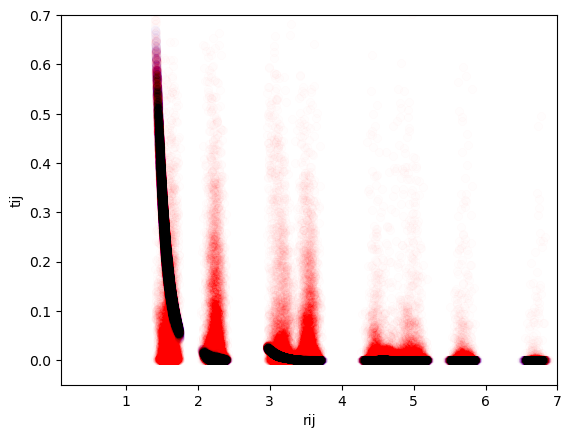

In [8]:
plt.scatter(
    dat["rij"][~mask].flatten(), dat["t_ij"][~mask].flatten(), color="r", alpha=2e-3
)
plt.scatter(
    dat["rij"][mask].flatten(), dat["t_ij"][mask].flatten(), color="blue", alpha=2e-3
)
plt.xlabel("rij")
plt.ylabel("tij")
plt.xlim(0.1, 7)
plt.ylim(-0.05, 0.7)

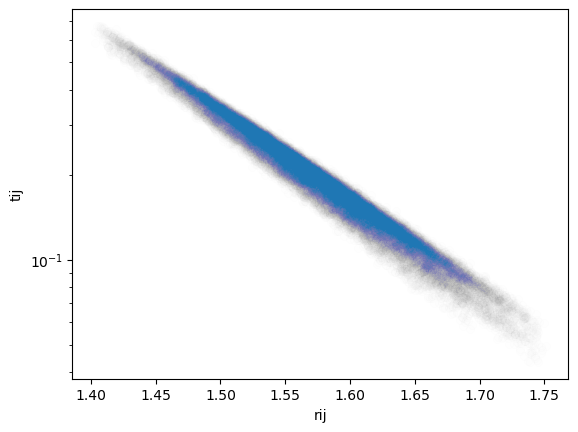

In [11]:
plt.scatter(nnr[mask].flatten(), nnt[mask].flatten(), alpha=2e-3)
plt.xlabel("rij")
plt.ylabel("tij")
plt.yscale("log")

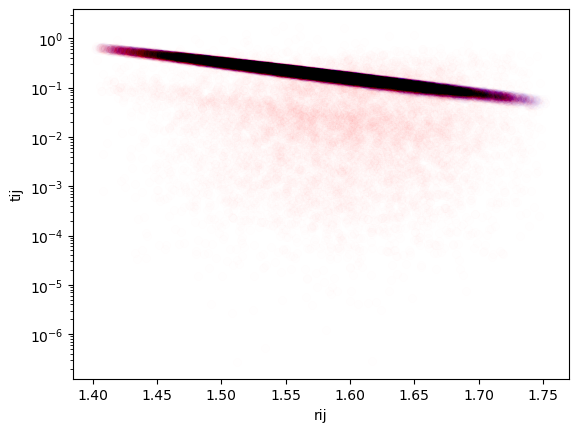

In [16]:
plt.scatter(nnr[~mask].flatten(), nnt[~mask].flatten(), color="r", alpha=5e-3)
plt.scatter(nnr[mask].flatten(), nnt[mask].flatten(), color="b", alpha=5e-3)

plt.xlabel("rij")
plt.ylabel("tij")
plt.yscale("log")

The above plots show a clear $e^{-r}$ decay instead of $e^{-r^2}$ by the Gaussian approximation of the Wannier function.

This is a clear sign that the Gaussian approximation is not valid for this system.

## Position effect

### t_12 vs t_15

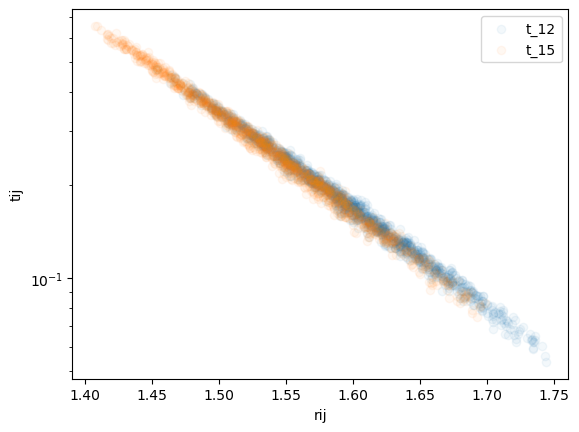

In [19]:
l1 = 0
l2 = 1
plt.scatter(
    dat["rij"][mask, l1, l2].flatten(),
    dat["t_ij"][mask, l1, l2].flatten(),
    alpha=5e-2,
    label=f"t_{l1+1}{l2+1}",
)
l1 = 0
l2 = 4
plt.scatter(
    dat["rij"][mask, l1, l2].flatten(),
    dat["t_ij"][mask, l1, l2].flatten(),
    alpha=5e-2,
    label=f"t_{l1+1}{l2+1}",
)
plt.legend()
plt.xlabel("rij")
plt.ylabel("tij")
plt.yscale("log")

### t_12 vs t_26

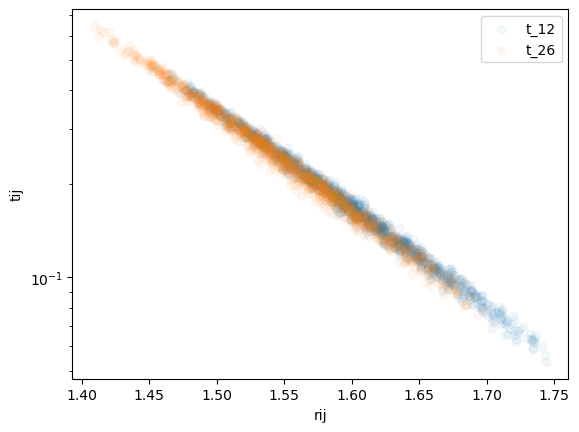

In [20]:
l1 = 0
l2 = 1
plt.scatter(
    dat["rij"][mask, l1, l2].flatten(),
    dat["t_ij"][mask, l1, l2].flatten(),
    alpha=5e-2,
    label=f"t_{l1+1}{l2+1}",
)
l1 = 1
l2 = 5
plt.scatter(
    dat["rij"][mask, l1, l2].flatten(),
    dat["t_ij"][mask, l1, l2].flatten(),
    alpha=5e-2,
    label=f"t_{l1+1}{l2+1}",
)
plt.legend()
plt.xlabel("rij")
plt.ylabel("tij")
plt.yscale("log")

### t_56 vs t_59

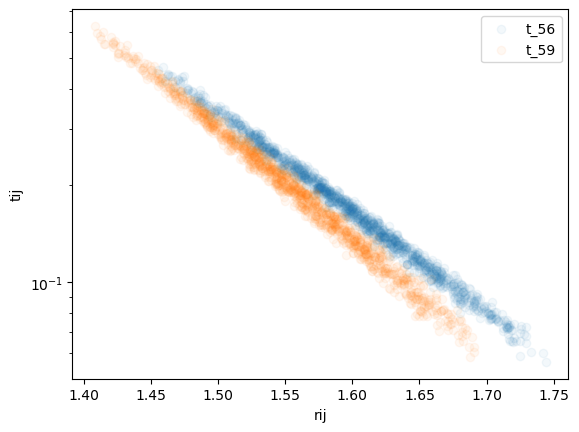

In [21]:
l1 = 4
l2 = 5
plt.scatter(
    dat["rij"][mask, l1, l2].flatten(),
    dat["t_ij"][mask, l1, l2].flatten(),
    alpha=5e-2,
    label=f"t_{l1+1}{l2+1}",
)
l1 = 4
l2 = 8
plt.scatter(
    dat["rij"][mask, l1, l2].flatten(),
    dat["t_ij"][mask, l1, l2].flatten(),
    alpha=5e-2,
    label=f"t_{l1+1}{l2+1}",
)
plt.legend()
plt.xlabel("rij")
plt.ylabel("tij")
plt.yscale("log")

### t_67 vs t_6,10

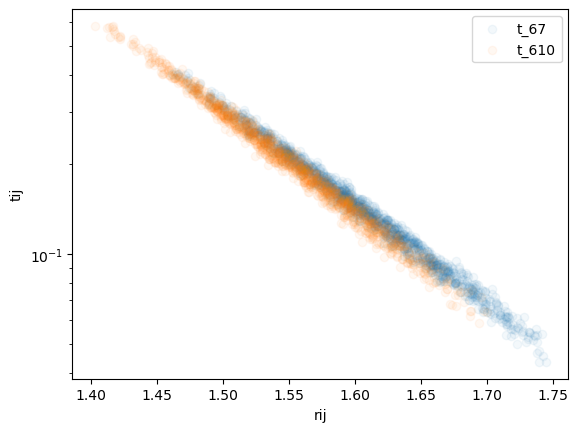

In [22]:
l1 = 5
l2 = 6
plt.scatter(
    dat["rij"][mask, l1, l2].flatten(),
    dat["t_ij"][mask, l1, l2].flatten(),
    alpha=5e-2,
    label=f"t_{l1+1}{l2+1}",
)
l1 = 5
l2 = 9
plt.scatter(
    dat["rij"][mask, l1, l2].flatten(),
    dat["t_ij"][mask, l1, l2].flatten(),
    alpha=5e-2,
    label=f"t_{l1+1}{l2+1}",
)
plt.legend()
plt.xlabel("rij")
plt.ylabel("tij")
plt.yscale("log")

## boundary effect

### horizontal

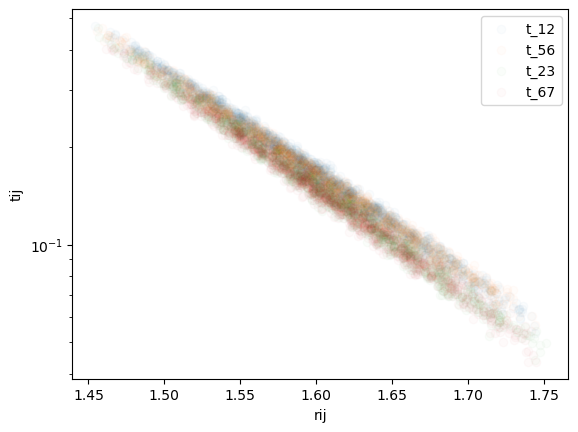

In [25]:
l1 = 0
l2 = 1
plt.scatter(
    dat["rij"][mask, l1, l2].flatten(),
    dat["t_ij"][mask, l1, l2].flatten(),
    alpha=2e-2,
    label=f"t_{l1+1}{l2+1}",
)
l1 = 4
l2 = 5
plt.scatter(
    dat["rij"][mask, l1, l2].flatten(),
    dat["t_ij"][mask, l1, l2].flatten(),
    alpha=2e-2,
    label=f"t_{l1+ 1}{l2+1}",
)
l1 = 1
l2 = 2
plt.scatter(
    dat["rij"][mask, l1, l2].flatten(),
    dat["t_ij"][mask, l1, l2].flatten(),
    alpha=2e-2,
    label=f"t_{l1+ 1}{l2+1}",
)
l1 = 5
l2 = 6
plt.scatter(
    dat["rij"][mask, l1, l2].flatten(),
    dat["t_ij"][mask, l1, l2].flatten(),
    alpha=2e-2,
    label=f"t_{l1+ 1}{l2+1}",
)
plt.legend()
plt.xlabel("rij")
plt.ylabel("tij")
plt.yscale("log")

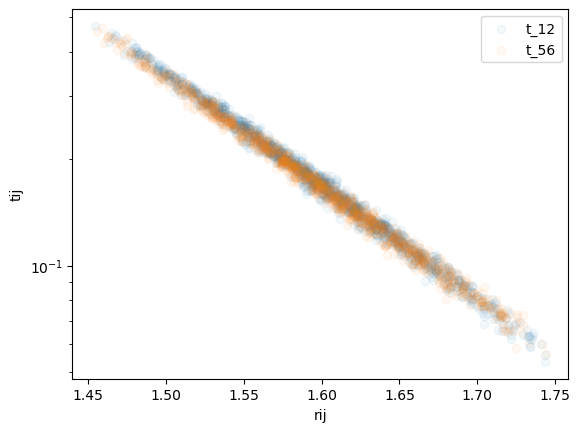

In [27]:
l1 = 0
l2 = 1
plt.scatter(
    dat["rij"][mask, l1, l2].flatten(),
    dat["t_ij"][mask, l1, l2].flatten(),
    alpha=5e-2,
    label=f"t_{l1+1}{l2+1}",
)
l1 = 4
l2 = 5
plt.scatter(
    dat["rij"][mask, l1, l2].flatten(),
    dat["t_ij"][mask, l1, l2].flatten(),
    alpha=5e-2,
    label=f"t_{l1+ 1}{l2+1}",
)
plt.legend()
plt.xlabel("rij")
plt.ylabel("tij")
plt.yscale("log")

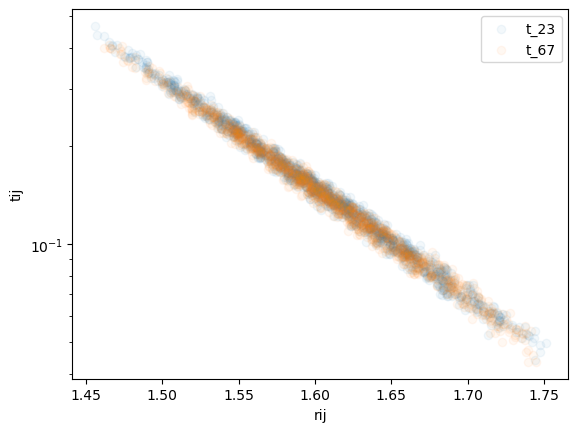

In [28]:
l1 = 1
l2 = 2
plt.scatter(
    dat["rij"][mask, l1, l2].flatten(),
    dat["t_ij"][mask, l1, l2].flatten(),
    alpha=5e-2,
    label=f"t_{l1+ 1}{l2+1}",
)
l1 = 5
l2 = 6
plt.scatter(
    dat["rij"][mask, l1, l2].flatten(),
    dat["t_ij"][mask, l1, l2].flatten(),
    alpha=5e-2,
    label=f"t_{l1+ 1}{l2+1}",
)
plt.legend()
plt.xlabel("rij")
plt.ylabel("tij")
plt.yscale("log")

### vertical

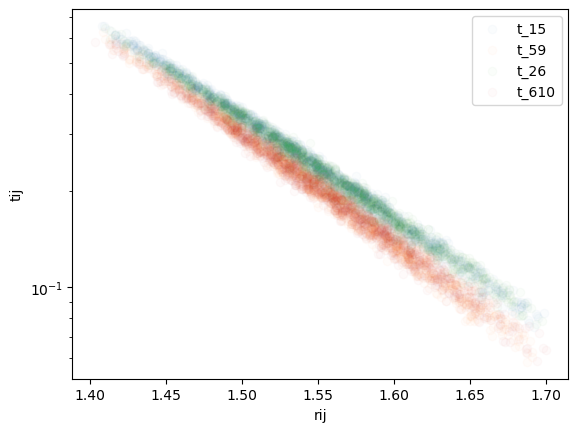

In [29]:
l1 = 0
l2 = 4
plt.scatter(
    dat["rij"][mask, l1, l2].flatten(),
    dat["t_ij"][mask, l1, l2].flatten(),
    alpha=2e-2,
    label=f"t_{l1+1}{l2+1}",
)
l1 = 4
l2 = 8
plt.scatter(
    dat["rij"][mask, l1, l2].flatten(),
    dat["t_ij"][mask, l1, l2].flatten(),
    alpha=2e-2,
    label=f"t_{l1+ 1}{l2+1}",
)
l1 = 1
l2 = 5
plt.scatter(
    dat["rij"][mask, l1, l2].flatten(),
    dat["t_ij"][mask, l1, l2].flatten(),
    alpha=2e-2,
    label=f"t_{l1+ 1}{l2+1}",
)
l1 = 5
l2 = 9
plt.scatter(
    dat["rij"][mask, l1, l2].flatten(),
    dat["t_ij"][mask, l1, l2].flatten(),
    alpha=2e-2,
    label=f"t_{l1+ 1}{l2+1}",
)
plt.legend()
plt.xlabel("rij")
plt.ylabel("tij")
plt.yscale("log")

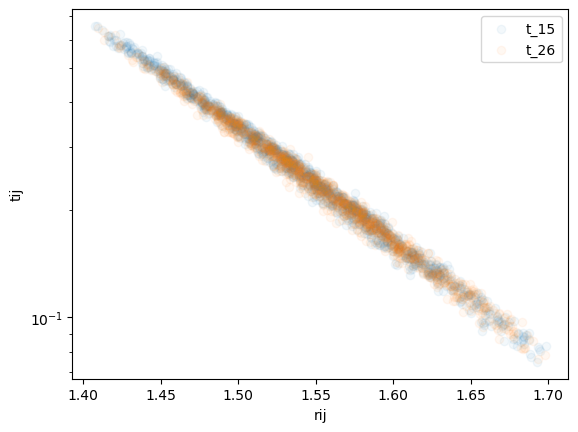

In [30]:
l1 = 0
l2 = 4
plt.scatter(
    dat["rij"][mask, l1, l2].flatten(),
    dat["t_ij"][mask, l1, l2].flatten(),
    alpha=5e-2,
    label=f"t_{l1+1}{l2+1}",
)
l1 = 1
l2 = 5
plt.scatter(
    dat["rij"][mask, l1, l2].flatten(),
    dat["t_ij"][mask, l1, l2].flatten(),
    alpha=5e-2,
    label=f"t_{l1+ 1}{l2+1}",
)
plt.legend()
plt.xlabel("rij")
plt.ylabel("tij")
plt.yscale("log")

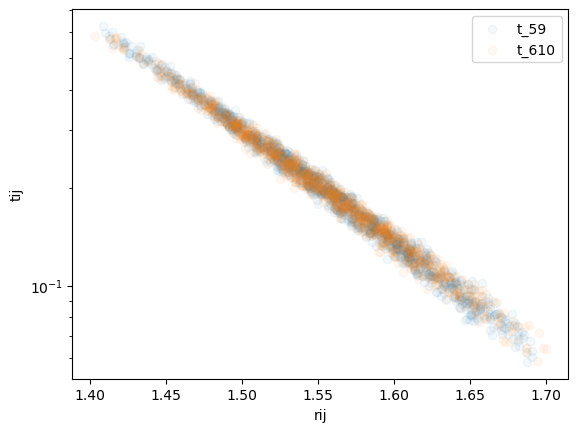

In [31]:
l1 = 4
l2 = 8
plt.scatter(
    dat["rij"][mask, l1, l2].flatten(),
    dat["t_ij"][mask, l1, l2].flatten(),
    alpha=5e-2,
    label=f"t_{l1+ 1}{l2+1}",
)
l1 = 5
l2 = 9
plt.scatter(
    dat["rij"][mask, l1, l2].flatten(),
    dat["t_ij"][mask, l1, l2].flatten(),
    alpha=5e-2,
    label=f"t_{l1+ 1}{l2+1}",
)
plt.legend()
plt.xlabel("rij")
plt.ylabel("tij")
plt.yscale("log")

## Depth effect

In [ ]:
Vij = dat["V_offset"][mask][:, links[:, 0]] + dat["V_offset"][mask][:, links[:, 1]]
plt.scatter(
    Vij / 2,
    nnt[mask],
    color="blue",
    alpha=2e-3,
)
plt.xlabel("(Vi + Vj) / 2")
plt.ylabel("tij")
# plt.xlim(0.1, 7)
# plt.ylim(-0.05, 0.7)

Text(0, 0.5, 'tij')

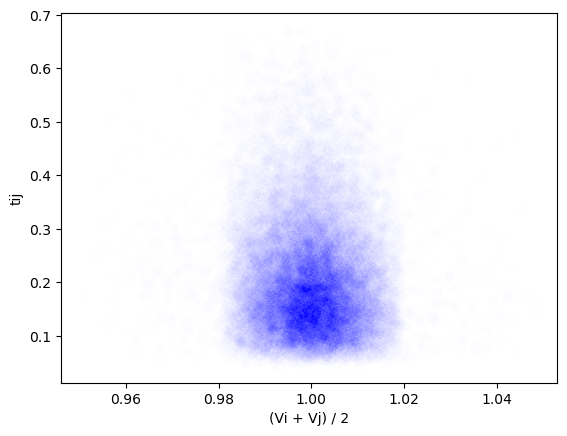

In [133]:
Vij = dat["V_offset"][mask][:, links[:, 0]] + dat["V_offset"][mask][:, links[:, 1]]
plt.scatter(
    Vij / 2,
    nnt[mask],
    color="blue",
    alpha=2e-3,
)
plt.xlabel("(Vi + Vj) / 2")
plt.ylabel("tij")
# plt.xlim(0.1, 7)
# plt.ylim(-0.05, 0.7)

Text(0, 0.5, 'tij')

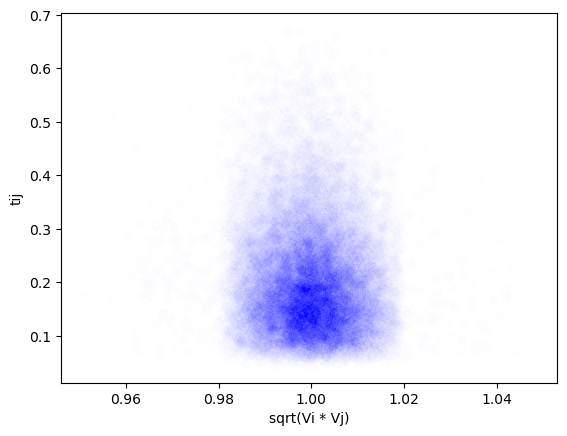

In [131]:
Vij = dat["V_offset"][mask][:, links[:, 0]] * dat["V_offset"][mask][:, links[:, 1]]
plt.scatter(
    np.sqrt(Vij),
    nnt[mask],
    color="blue",
    alpha=2e-3,
)
plt.xlabel("sqrt(Vi * Vj)")
plt.ylabel("tij")
# plt.xlim(0.1, 7)
# plt.ylim(-0.05, 0.7)

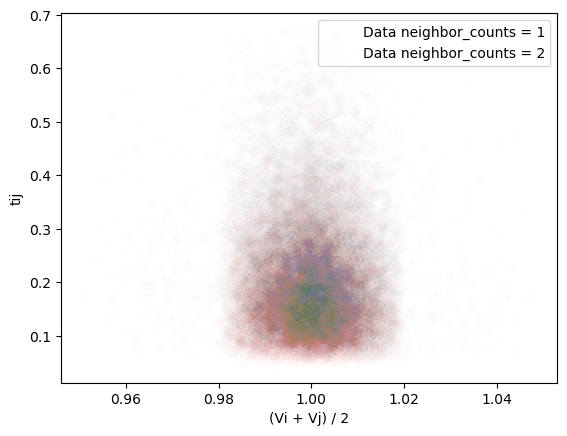

In [20]:
for i in [1, 2]:
    Vij = (
        dat["V_offset"][mask][:, links[neighbor_counts == i, 0]]
        + dat["V_offset"][mask][:, links[neighbor_counts == i, 1]]
    ) / 2
    plt.scatter(
        Vij,
        nnt[mask][:, neighbor_counts == i],
        alpha=2e-3,
        label="Data neighbor_counts = " + str(i),
    )
plt.xlabel("(Vi + Vj) / 2")
plt.ylabel("tij")
plt.legend()

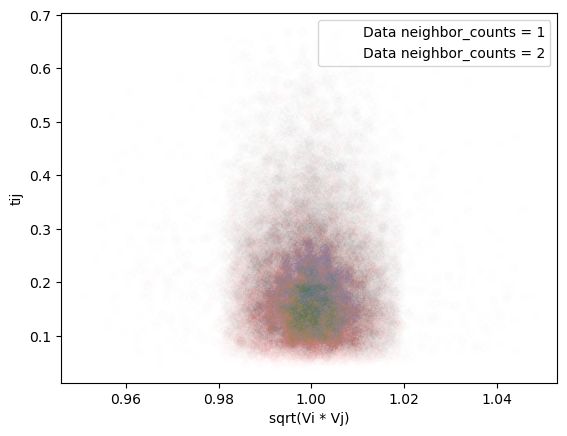

In [21]:
for i in [1, 2]:
    Vij = np.sqrt(
        dat["V_offset"][mask][:, links[neighbor_counts == i, 0]]
        * dat["V_offset"][mask][:, links[neighbor_counts == i, 1]]
    )
    plt.scatter(
        Vij,
        nnt[mask][:, neighbor_counts == i],
        alpha=2e-3,
        label="Data neighbor_counts = " + str(i),
    )
plt.xlabel("sqrt(Vi * Vj)")
plt.ylabel("tij")
plt.legend()

### Depth effect at fixed distance

Text(0, 0.5, 'tij')

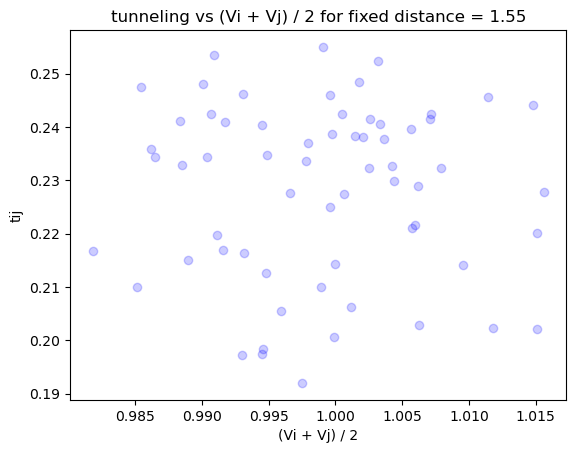

In [48]:
dist = 1.55
fix_dist = np.abs(dat["rij"][mask][:, links[:, 0], links[:, 1]] - dist) < 2e-4

Vij = dat["V_offset"][mask][:, links[:, 0]] + dat["V_offset"][mask][:, links[:, 1]]
plt.scatter(
    Vij[fix_dist] / 2,
    nnt[mask][fix_dist],
    color="blue",
    alpha=0.2,
)
plt.title(f"tunneling vs (Vi + Vj) / 2 for fixed distance = {dist}")
plt.xlabel("(Vi + Vj) / 2")
plt.ylabel("tij")

Text(0, 0.5, 'tij')

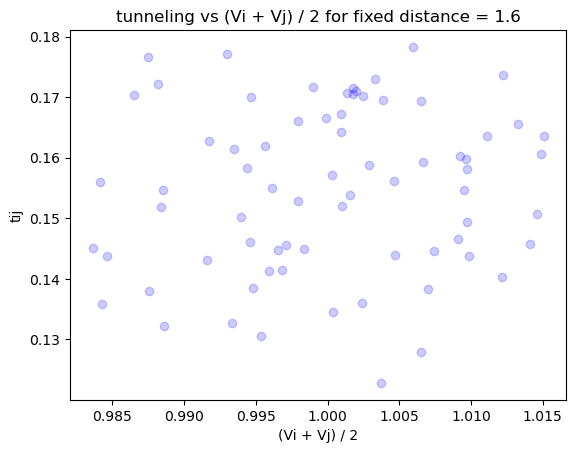

In [50]:
dist = 1.6
fix_dist = np.abs(dat["rij"][mask][:, links[:, 0], links[:, 1]] - dist) < 2e-4

Vij = dat["V_offset"][mask][:, links[:, 0]] + dat["V_offset"][mask][:, links[:, 1]]
plt.scatter(
    Vij[fix_dist] / 2,
    nnt[mask][fix_dist],
    color="blue",
    alpha=0.2,
)
plt.title(f"tunneling vs (Vi + Vj) / 2 for fixed distance = {dist}")
plt.xlabel("(Vi + Vj) / 2")
plt.ylabel("tij")
# plt.xlim(0.1, 7)
# plt.ylim(-0.05, 0.7)

Text(0, 0.5, 'tij')

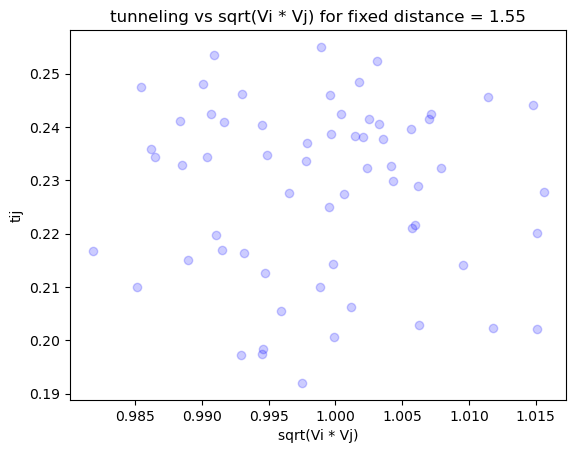

In [51]:
dist = 1.55
fix_dist = np.abs(dat["rij"][mask][:, links[:, 0], links[:, 1]] - dist) < 2e-4

Vij = dat["V_offset"][mask][:, links[:, 0]] * dat["V_offset"][mask][:, links[:, 1]]
plt.scatter(
    np.sqrt(Vij[fix_dist]),
    nnt[mask][fix_dist],
    color="blue",
    alpha=0.2,
)
plt.title(f"tunneling vs sqrt(Vi * Vj) for fixed distance = {dist}")
plt.xlabel("sqrt(Vi * Vj)")
plt.ylabel("tij")

Text(0, 0.5, 'tij')

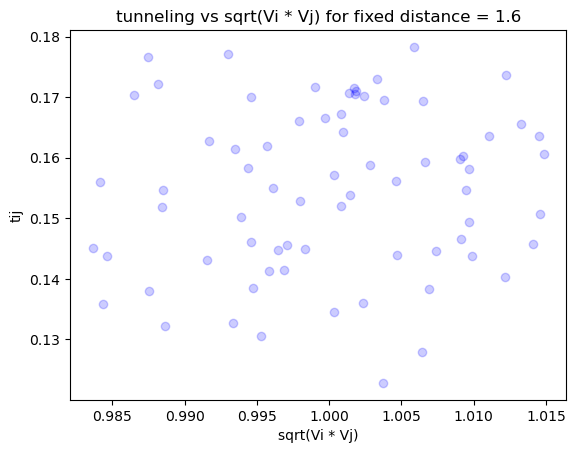

In [52]:
dist = 1.6
fix_dist = np.abs(dat["rij"][mask][:, links[:, 0], links[:, 1]] - dist) < 2e-4

Vij = dat["V_offset"][mask][:, links[:, 0]] * dat["V_offset"][mask][:, links[:, 1]]
plt.scatter(
    np.sqrt(Vij[fix_dist]),
    nnt[mask][fix_dist],
    color="blue",
    alpha=0.2,
)
plt.title(f"tunneling vs sqrt(Vi * Vj) for fixed distance = {dist}")
plt.xlabel("sqrt(Vi * Vj)")
plt.ylabel("tij")

## With fixed number of neighboring atoms

In [196]:
X = nnr[mask]
Y = nnt[mask]


def get_neighbors(grid_size, edges):
    # For each edge, find the index of the neighbors
    grid_width, grid_height = grid_size

    # Helper function to get the row and column from vertex index
    def get_row_col(vertex, width):
        return vertex // width, vertex % width

    def get_idx(role, col, grid_width):
        return role * grid_width + col

    # Initialize the count array
    neighbor_counts = []
    other_neighbor = []

    for edge in edges:
        count = 0
        neighbor = []

        # Get row and column for both vertices
        row, col = get_row_col(edge, grid_width)

        # Determine the edge orientation and count neighbors
        if np.diff(row):  # Horizontal (x) edge
            # Check left and right neighbors
            row.sort()
            if row[0] > 0:
                neighbor.append(
                    [
                        get_idx(row[0], col[0], grid_width),
                        get_idx(row[0] - 1, col[0], grid_width),
                    ]
                )
                count += 1
            if row[1] < grid_height - 1:
                neighbor.append(
                    [
                        get_idx(row[1], col[1], grid_width),
                        get_idx(row[1] + 1, col[1], grid_width),
                    ]
                )
                count += 1
        elif np.diff(col):  # Vertical (y) edge
            # Check top and bottom neighbors
            col.sort()
            if col[0] > 0:
                neighbor.append(
                    [
                        get_idx(row[0], col[0], grid_width),
                        get_idx(row[0], col[0] - 1, grid_width),
                    ]
                )
                count += 1
            if col[1] < grid_width - 1:
                neighbor.append(
                    [
                        get_idx(row[1], col[1], grid_width),
                        get_idx(row[1], col[1] + 1, grid_width),
                    ]
                )
                count += 1
        neighbor_counts.append(count)
        other_neighbor.append(neighbor)
    return np.array(neighbor_counts), other_neighbor


# Example Usage
grid = [4, 4]
edges = links

neighbor_counts, other_neighbor = get_neighbors(grid, edges)
for i in range(len(edges)):
    print(f"Edge {i}: {edges[i]} neighbors: {neighbor_counts[i]} {other_neighbor[i]}")

Edge 0: [0 1] neighbors: 1 [[np.int64(1), np.int64(2)]]
Edge 1: [1 2] neighbors: 2 [[np.int64(1), np.int64(0)], [np.int64(2), np.int64(3)]]
Edge 2: [2 3] neighbors: 1 [[np.int64(2), np.int64(1)]]
Edge 3: [0 4] neighbors: 1 [[np.int64(4), np.int64(8)]]
Edge 4: [1 5] neighbors: 1 [[np.int64(5), np.int64(9)]]
Edge 5: [4 5] neighbors: 1 [[np.int64(5), np.int64(6)]]
Edge 6: [2 6] neighbors: 1 [[np.int64(6), np.int64(10)]]
Edge 7: [5 6] neighbors: 2 [[np.int64(5), np.int64(4)], [np.int64(6), np.int64(7)]]
Edge 8: [3 7] neighbors: 1 [[np.int64(7), np.int64(11)]]
Edge 9: [6 7] neighbors: 1 [[np.int64(6), np.int64(5)]]
Edge 10: [4 8] neighbors: 2 [[np.int64(4), np.int64(0)], [np.int64(8), np.int64(12)]]
Edge 11: [5 9] neighbors: 2 [[np.int64(5), np.int64(1)], [np.int64(9), np.int64(13)]]
Edge 12: [8 9] neighbors: 1 [[np.int64(9), np.int64(10)]]
Edge 13: [ 6 10] neighbors: 2 [[np.int64(6), np.int64(2)], [np.int64(10), np.int64(14)]]
Edge 14: [ 9 10] neighbors: 2 [[np.int64(9), np.int64(8)], [np.

### neighobr_count = 1 samples

In [ ]:
neighbor_links = []
for i in range(len(other_neighbor)):
    if neighbor_counts[i] == 1:
        neighbor_links.append(other_neighbor[i])
neighbor_links = np.array(neighbor_links)

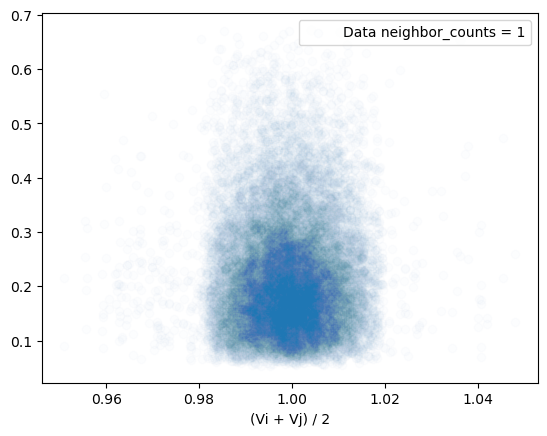

In [220]:
Vij = (
    dat["V_offset"][mask][:, neighbor_links[:, 0]]
    + dat["V_offset"][mask][:, neighbor_links[:, 1]]
) / 2
plt.scatter(
    Vij.flatten(),
    Y[:, neighbor_counts == 1].flatten(),
    label="Data neighbor_counts = " + str(1),
    alpha=1e-2,
)
plt.xlabel("(Vi + Vj) / 2")
plt.legend()

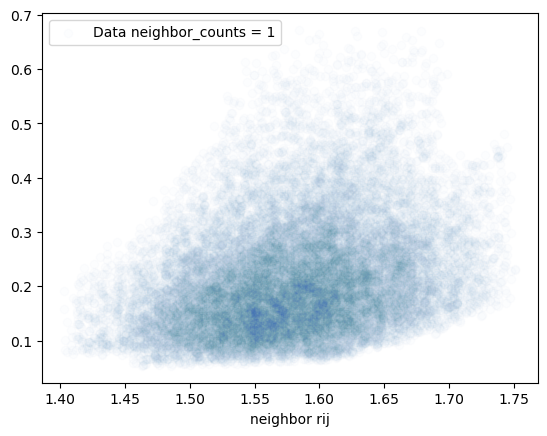

In [221]:
rij_neighbor = dat["rij"][mask][:, neighbor_links[:, 0], neighbor_links[:, 1]]
plt.scatter(
    rij_neighbor.flatten(),
    Y[:, neighbor_counts == 1].flatten(),
    label="Data neighbor_counts = " + str(1),
    alpha=1e-2,
)
plt.xlabel("neighbor rij")
plt.legend()

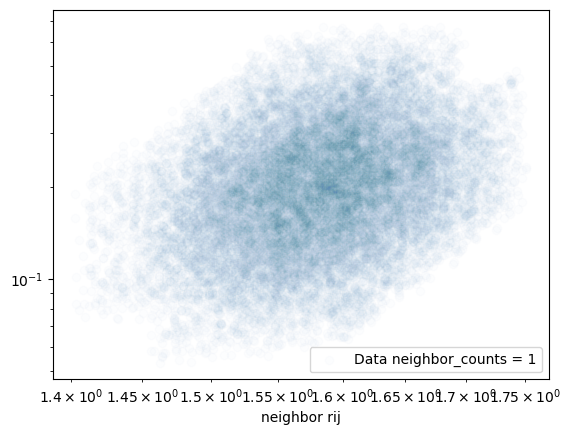

In [222]:
rij_neighbor = dat["rij"][mask][:, neighbor_links[:, 0], neighbor_links[:, 1]]
plt.scatter(
    rij_neighbor.flatten(),
    Y[:, neighbor_counts == 1].flatten(),
    label="Data neighbor_counts = " + str(1),
    alpha=1e-2,
)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("neighbor rij")
plt.legend()

Fitted power law: Y = 0.0458 * rij^3.4206


Text(0.5, 1.0, 'Power Law Fit for neighbor_counts == 1')

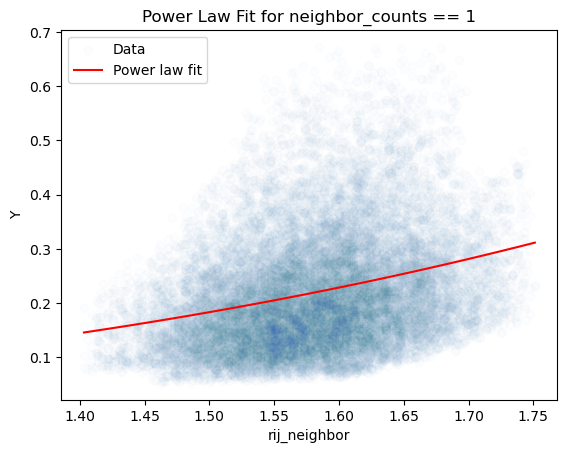

In [229]:
# Prepare data for neighbor_counts == 1
xdata = rij_neighbor.flatten()
ydata = Y[:, neighbor_counts == 1].flatten()


# Define power law function
def power_law(x, a, b):
    return a * np.power(x, b)


# Fit the data
popt, pcov = curve_fit(power_law, xdata, ydata, p0=[1, 3], maxfev=100)

a_fit, b_fit = popt
print(f"Fitted power law: Y = {a_fit:.4f} * rij^{b_fit:.4f}")

# Plot data and fit
plt.scatter(xdata, ydata, alpha=1e-2, label="Data")
x_fit = np.linspace(np.min(xdata), np.max(xdata), 100)
plt.plot(x_fit, power_law(x_fit, *popt), color="red", label="Power law fit")
plt.xlabel("rij_neighbor")
plt.ylabel("Y")
plt.legend()
plt.title("Power Law Fit for neighbor_counts == 1")

### neighobr_count = 2 samples

In [202]:
neighbor_links = []
for i in range(len(other_neighbor)):
    if neighbor_counts[i] == 2:
        neighbor_links.append(other_neighbor[i])
neighbor_links = np.array(neighbor_links)

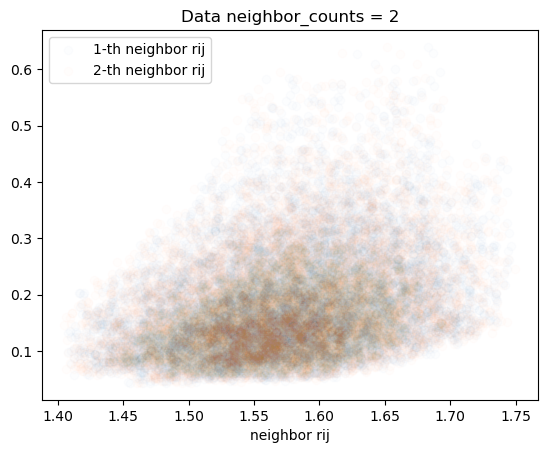

In [205]:
for i in range(2):
    rij_neighbors = dat["rij"][mask][
        :, neighbor_links[:, i, 0], neighbor_links[:, i, 1]
    ]
    plt.scatter(
        rij_neighbors,
        Y[:, neighbor_counts == 2],
        label=f"{i+1}-th neighbor rij",
        alpha=1e-2,
    )
plt.title("Data neighbor_counts = " + str(2))
plt.xlabel("neighbor rij")
plt.legend()

/var/folders/v_/57lcwyys42x6cnvvnbz7gk4h0000gn/T/ipykernel_2008/1326874563.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


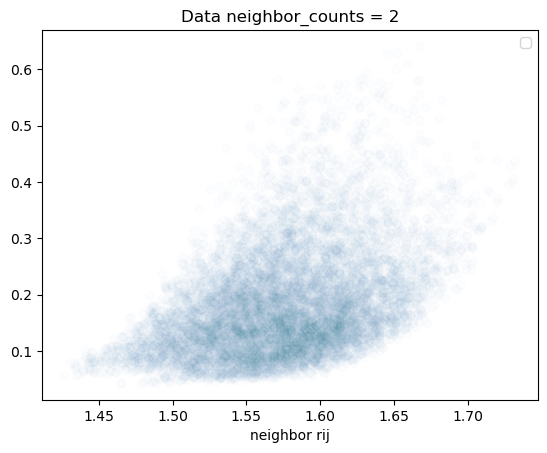

In [213]:
rij_neighbors = dat["rij"][mask][
    :, neighbor_links[:, [0, 1], 0], neighbor_links[:, [0, 1], 1]
]
plt.scatter(
    np.mean(rij_neighbors, axis=-1),
    Y[:, neighbor_counts == 2],
    # label=f"{i+1}-th neighbor rij",
    alpha=1e-2,
)
plt.title("Data neighbor_counts = " + str(2))
plt.xlabel("neighbor rij")
plt.legend()

## Summary

n.n. tunneling can be classified as two types depending on which bond they are at. This is independent of direction. The two types are:

1. Type 1: t_12, t_15, t_56, t_26
2. Type 2: t_23, t_67, t_59, t_6,10

How to characterize the two types?
1. The difference is only the environment on the direction of the bond.
2. Try add the neighboring number of atoms along the bond direction.

# Fit the data

## Single factor rij

NOTE: MSELoss is the same as cost function usually used in regression.

Sort the data.

In [32]:
X = nnr[mask].flatten()
arg = np.argsort(X)
X = X[arg]
Y = nnt[mask].flatten()
Y = Y[arg]

### Exponential fitting

In [ ]:
# Custom Model for Exponential Fitting
class ExponentialModel(nn.Module):
    def __init__(self):
        super(ExponentialModel, self).__init__()
        self.a = nn.Parameter(torch.randn(()))  # Initialize the 'a' parameter
        self.b = nn.Parameter(torch.randn(()))  # Initialize the 'b' parameter

    def forward(self, x):
        return self.b * torch.exp(self.a * x)


# Convert data to torch tensors
X_torch = torch.tensor(X, dtype=torch.float64)
Y_torch = torch.tensor(Y, dtype=torch.float64)

# Initialize the model
model = ExponentialModel()


def criterion(outputs, targets):
    # Define the MSE loss
    mse_loss = nn.MSELoss()

    # Inside your training loop
    loss = mse_loss(outputs, targets) / (
        torch.var(targets) if torch.var(targets) != 0 else 1.0
    )
    return loss


def regression(X, Y, model: nn.Module, maxiter=1000, tol=1e-9):
    # optimizer = optim.SGD(model.parameters(), lr=0.01)
    # optimizer = optim.Adam(model.parameters(), lr=0.01)
    # Using L-BFGS Optimizer
    optimizer = optim.LBFGS(
        model.parameters(),
        lr=0.005,
        max_iter=maxiter,
        tolerance_grad=tol * 1e2,
        tolerance_change=tol,
    )

    # Training Loop
    loss_old = torch.inf
    loss_new = torch.inf

    def closure():
        optimizer.zero_grad()
        outputs = model(X)
        loss = criterion(outputs, Y)
        loss.backward()
        return loss

    # Training Loop
    for epoch in range(maxiter):  # Number of epochs
        if loss_old - loss_new < tol:
            break
        loss_old = loss_new

        optimizer.step(closure)
        loss = closure().item()
        loss_new = loss
        # # Forward pass
        # outputs = model(X_torch)
        # loss = criterion(outputs, Y_torch)
        # loss_new = loss.item()
        if epoch % 1 == 0:
            print(f"Epoch [{epoch+1}/{maxiter}], Loss: {loss_new:.4f}")
        # # Backward and optimize
        # optimizer.zero_grad()
        # loss.backward()
        # optimizer.step()

    print(f"Final Loss: {loss_new:.4f}")
    return model


def r_squared(X, Y, model: nn.Module):
    # Step 1: Predict Outputs
    model.eval()  # Set the model to evaluation mode
    with torch.no_grad():
        predictions = model(X)

    # Step 2: Calculate SST
    sst = torch.std(Y) ** 2
    # Step 3: Calculate SSR
    ssr = torch.mean((Y - predictions) ** 2)

    # Step 4: Compute R^2
    r2 = 1 - ssr / sst
    return r2.item()


model = regression(X_torch, Y_torch, model)
r2 = r_squared(X_torch, Y_torch, model)

a = model.a.item()
b = model.b.item()

print(f"Exponential model: Y = {b} * exp({a} * X)")
print(f"R^2 Score: {r2}")

Epoch [1/1000], Loss: 0.5307
Epoch [2/1000], Loss: 0.1636
Epoch [3/1000], Loss: 0.0339
Epoch [4/1000], Loss: 0.0228
Epoch [5/1000], Loss: 0.0228
Epoch [6/1000], Loss: 0.0228
Epoch [7/1000], Loss: 0.0228
Final Loss: 0.0228
Exponential model: Y = 19959.87109375 * exp(-7.3415398597717285 * X)
R^2 Score: 0.9771669062321128


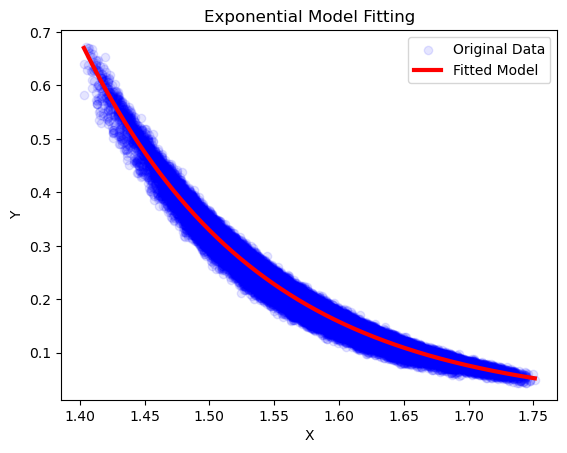

In [ ]:
# Generate predictions from the model
with torch.no_grad():  # We don't need gradients for prediction
    predicted = model(X_torch).numpy()

# Plotting the original data
plt.scatter(X, Y, color="blue", label="Original Data", alpha=0.1)

# Plotting the model's predictions
plt.plot(X, predicted, color="red", label="Fitted Model", linewidth=3)

# Adding labels and title
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Exponential Model Fitting")
plt.legend()
# plt.yscale("log")

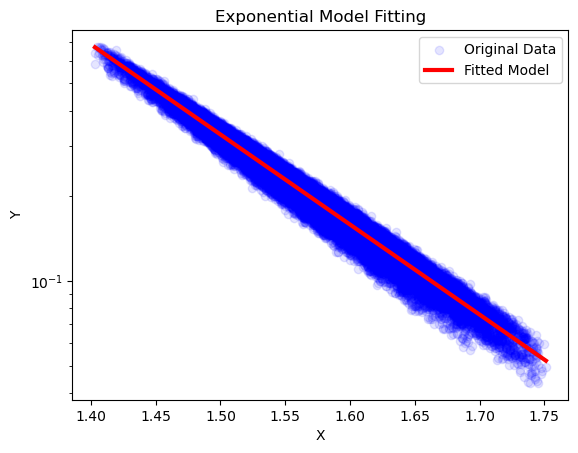

In [ ]:
# Generate predictions from the model
with torch.no_grad():  # We don't need gradients for prediction
    predicted = model(X_torch).numpy()

# Plotting the original data
plt.scatter(X, Y, color="blue", label="Original Data", alpha=0.1)

# Plotting the model's predictions
plt.plot(X, predicted, color="red", label="Fitted Model", linewidth=3)

# Adding labels and title
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Exponential Model Fitting")
plt.legend()
plt.yscale("log")

Text(0.5, 1.0, 'Histogram of Residuals')

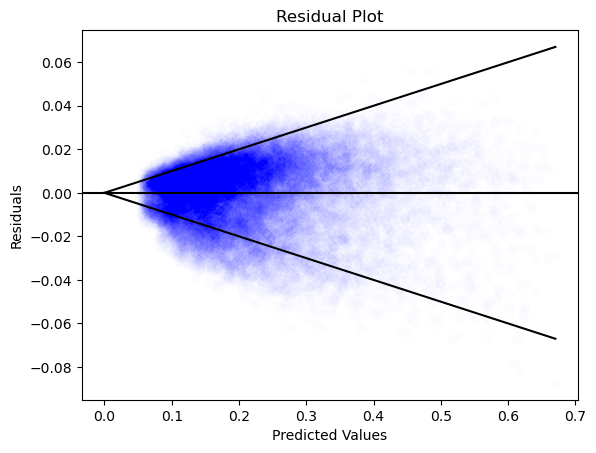

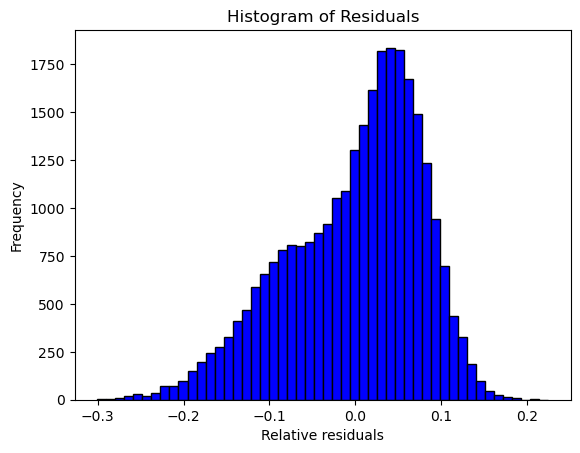

In [ ]:
# Function to calculate residuals
def calculate_residuals(model, X, Y):
    model.eval()  # Set the model to evaluation mode
    with torch.no_grad():
        predictions = model(X)
    residuals = Y - predictions
    return predictions, residuals


# Calculate residuals
predictions, residuals = calculate_residuals(model, X_torch, Y_torch)

# Convert to numpy for plotting
predictions_np = predictions.numpy().flatten()
residuals_np = residuals.numpy().flatten()

# Plotting residuals
plt.figure()
plt.scatter(predictions_np, residuals_np, color="blue", alpha=8e-3)
plt.axhline(y=0, color="k", linestyle="-")
x = np.linspace(0, np.max(predictions_np), 100)
plt.plot(x, 0.1 * x, color="k")
plt.plot(x, -0.1 * x, color="k")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")

# Optional: Histogram of Residuals
plt.figure()
plt.hist(residuals_np / predictions_np, bins=50, color="blue", edgecolor="black")
plt.xlabel("Relative residuals")
plt.ylabel("Frequency")
plt.title("Histogram of Residuals")

There is clearly 2 shopulders on both hand sides.

### Linear fitting on log scale

In [ ]:
class LinearModel(nn.Module):
    def __init__(self):
        super(LinearModel, self).__init__()
        self.a = nn.Parameter(-2 * torch.ones(1))  # Initialize the 'a' parameter
        self.b = nn.Parameter(2 * torch.ones(1))  # Initialize the 'b' parameter

    def forward(self, x):
        return self.a * x + self.b


# Convert data to torch tensors
X_torch = torch.tensor(X, dtype=torch.float32)
Y_torch = torch.tensor(Y, dtype=torch.float32)
# Assuming X and Y are your data arrays
Y_log = torch.log(Y_torch)  # Take the logarithm of Y

# Initialize the model
model = LinearModel()


def criterion(outputs, targets):
    # Restore original scale of Y
    targets = torch.exp(targets)
    outputs = torch.exp(outputs)

    # Define the MSE loss
    mse_loss = nn.MSELoss()

    # Inside your training loop
    loss = mse_loss(outputs, targets) / (
        torch.var(targets) if torch.var(targets) != 0 else 1.0
    )
    return loss


def regression(X, Y, model: nn.Module, maxiter=1000, tol=1e-9):
    # optimizer = optim.SGD(model.parameters(), lr=0.01)
    # Using L-BFGS Optimizer
    optimizer = optim.LBFGS(
        model.parameters(),
        lr=0.005,
        max_iter=maxiter,
        tolerance_grad=tol * 1e2,
        tolerance_change=tol,
    )

    # Training Loop
    loss_old = torch.inf
    loss_new = torch.inf

    def closure():
        optimizer.zero_grad()
        outputs = model(X)
        loss = criterion(outputs, Y)
        loss.backward()
        return loss

    # Training Loop
    for epoch in range(maxiter):  # Number of epochs
        if loss_old - loss_new < tol:
            break
        loss_old = loss_new

        optimizer.step(closure)
        loss = closure().item()
        loss_new = loss
        # # Forward pass
        # outputs = model(X_torch)
        # loss = criterion(outputs, Y_torch)
        # loss_new = loss.item()
        if epoch % 1 == 0:
            print(f"Epoch [{epoch+1}/{maxiter}], Loss: {loss_new:.4f}")
        # # Backward and optimize
        # optimizer.zero_grad()
        # loss.backward()
        # optimizer.step()

    print(f"Final Loss: {loss_new:.4f}")
    return model


def r_squared(X, Y, model: nn.Module):
    # Step 1: Predict Outputs
    model.eval()  # Set the model to evaluation mode
    with torch.no_grad():
        predictions = model(X)

    # Step 2: Calculate SST
    sst = torch.std(Y) ** 2
    # Step 3: Calculate SSR
    ssr = torch.mean((Y - predictions) ** 2)

    # Step 4: Compute R^2
    r2 = 1 - ssr / sst
    return r2.item()


model = regression(X_torch, Y_log, model)
r2 = r_squared(X_torch, Y_log, model)

a = model.a.item()
b = np.exp(model.b.item())

print(f"Exponential model: Y = {b} * exp({a} * X)")
print(f"R^2 Score: {r2}")

Epoch [1/1000], Loss: 0.0235
Epoch [2/1000], Loss: 0.0228
Epoch [3/1000], Loss: 0.0228
Epoch [4/1000], Loss: 0.0228
Epoch [5/1000], Loss: 0.0228
Epoch [6/1000], Loss: 0.0228
Epoch [7/1000], Loss: 0.0228
Epoch [8/1000], Loss: 0.0228
Epoch [9/1000], Loss: 0.0228
Epoch [10/1000], Loss: 0.0228
Epoch [11/1000], Loss: 0.0228
Epoch [12/1000], Loss: 0.0228
Epoch [13/1000], Loss: 0.0228
Epoch [14/1000], Loss: 0.0228
Epoch [15/1000], Loss: 0.0228
Epoch [16/1000], Loss: 0.0228
Epoch [17/1000], Loss: 0.0228
Final Loss: 0.0228
Exponential model: Y = 19926.941855504738 * exp(-7.34044075012207 * X)
R^2 Score: 0.9720325469970703


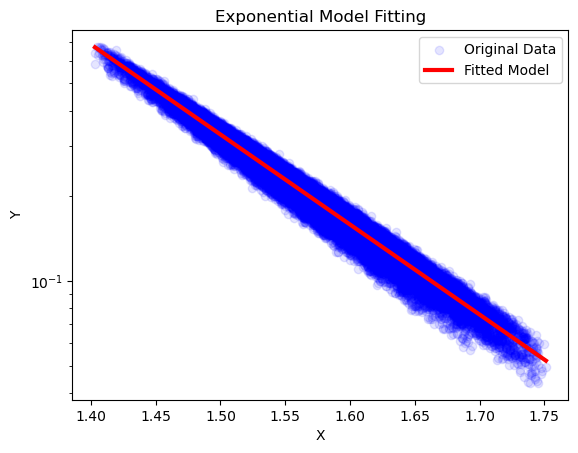

In [ ]:
# Generate predictions from the model
with torch.no_grad():  # We don't need gradients for prediction
    predicted = torch.exp(model(X_torch)).numpy()

# Plotting the original data
plt.scatter(X, Y, color="blue", label="Original Data", alpha=0.1)

# Plotting the model's predictions
plt.plot(X, predicted, color="red", label="Fitted Model", linewidth=3)

# Adding labels and title
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Exponential Model Fitting")
plt.legend()
plt.yscale("log")

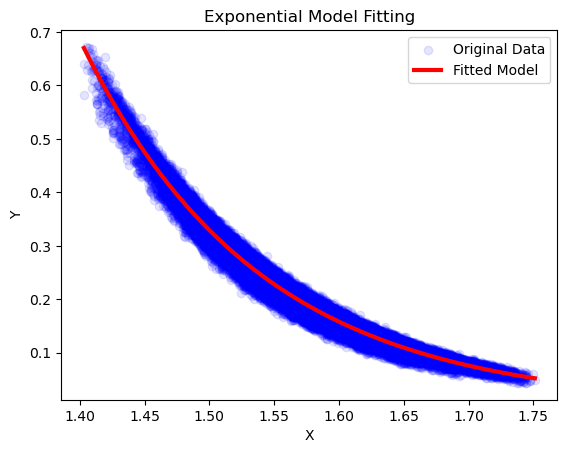

In [ ]:
# Generate predictions from the model
with torch.no_grad():  # We don't need gradients for prediction
    predicted = torch.exp(model(X_torch)).numpy()

# Plotting the original data
plt.scatter(X, Y, color="blue", label="Original Data", alpha=0.1)

# Plotting the model's predictions
plt.plot(X, predicted, color="red", label="Fitted Model", linewidth=3)

# Adding labels and title
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Exponential Model Fitting")
plt.legend()
# plt.yscale("log")

Text(0.5, 1.0, 'Histogram of Residuals')

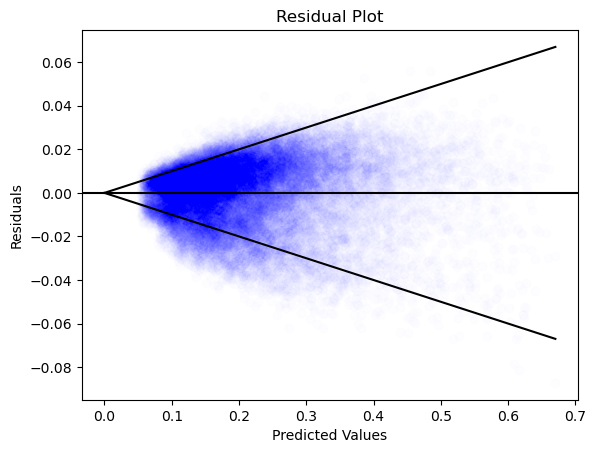

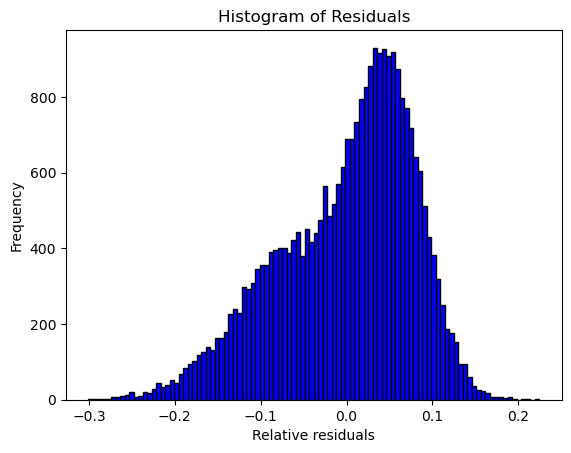

In [ ]:
# Function to calculate residuals
def calculate_residuals(model, X, Y):
    model.eval()  # Set the model to evaluation mode
    with torch.no_grad():
        predictions = torch.exp(model(X))
    residuals = Y - predictions
    return predictions, residuals


# Calculate residuals
predictions, residuals = calculate_residuals(model, X_torch, Y_torch)

# Convert to numpy for plotting
predictions_np = predictions.numpy().flatten()
residuals_np = residuals.numpy().flatten()

# Plotting residuals
plt.figure()
plt.scatter(predictions_np, residuals_np, color="blue", alpha=8e-3)
plt.axhline(y=0, color="k", linestyle="-")
x = np.linspace(0, np.max(predictions_np), 100)
plt.plot(x, 0.1 * x, color="k")
plt.plot(x, -0.1 * x, color="k")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")

# Optional: Histogram of Residuals
plt.figure()
plt.hist(residuals_np / predictions_np, bins=100, color="blue", edgecolor="black")
plt.xlabel("Relative residuals")
plt.ylabel("Frequency")
plt.title("Histogram of Residuals")

## Fit with neighboring atom numbers

Identify neighboring atom numbers.

In [19]:
X = nnr[mask]
Y = nnt[mask]


def get_neighbors(grid_size, edges):
    # For each edge, find the index of the neighbors
    grid_width, grid_height = grid_size

    # Helper function to get the row and column from vertex index
    def get_row_col(vertex, width):
        return vertex // width, vertex % width

    def get_idx(role, col, grid_width):
        return role * grid_width + col

    # Initialize the count array
    neighbor_counts = []
    other_neighbor = []

    for edge in edges:
        count = 0
        neighbor = []

        # Get row and column for both vertices
        row, col = get_row_col(edge, grid_width)

        # Determine the edge orientation and count neighbors
        if np.diff(row):  # Horizontal (x) edge
            # Check left and right neighbors
            row.sort()
            if row[0] > 0:
                neighbor.append(
                    [
                        get_idx(row[0], col[0], grid_width),
                        get_idx(row[0] - 1, col[0], grid_width),
                    ]
                )
                count += 1
            if row[1] < grid_height - 1:
                neighbor.append(
                    [
                        get_idx(row[1], col[1], grid_width),
                        get_idx(row[1] + 1, col[1], grid_width),
                    ]
                )
                count += 1
        elif np.diff(col):  # Vertical (y) edge
            # Check top and bottom neighbors
            col.sort()
            if col[0] > 0:
                neighbor.append(
                    [
                        get_idx(row[0], col[0], grid_width),
                        get_idx(row[0], col[0] - 1, grid_width),
                    ]
                )
                count += 1
            if col[1] < grid_width - 1:
                neighbor.append(
                    [
                        get_idx(row[1], col[1], grid_width),
                        get_idx(row[1], col[1] + 1, grid_width),
                    ]
                )
                count += 1
        neighbor_counts.append(count)
        other_neighbor.append(neighbor)
    return np.array(neighbor_counts), other_neighbor


# Example Usage
grid = [4, 4]
edges = links

neighbor_counts, other_neighbor = get_neighbors(grid, edges)
for i in range(len(edges)):
    print(f"Edge {i}: {edges[i]} neighbors: {neighbor_counts[i]} {other_neighbor[i]}")

Edge 0: [0 1] neighbors: 1 [[np.int64(1), np.int64(2)]]
Edge 1: [1 2] neighbors: 2 [[np.int64(1), np.int64(0)], [np.int64(2), np.int64(3)]]
Edge 2: [2 3] neighbors: 1 [[np.int64(2), np.int64(1)]]
Edge 3: [0 4] neighbors: 1 [[np.int64(4), np.int64(8)]]
Edge 4: [1 5] neighbors: 1 [[np.int64(5), np.int64(9)]]
Edge 5: [4 5] neighbors: 1 [[np.int64(5), np.int64(6)]]
Edge 6: [2 6] neighbors: 1 [[np.int64(6), np.int64(10)]]
Edge 7: [5 6] neighbors: 2 [[np.int64(5), np.int64(4)], [np.int64(6), np.int64(7)]]
Edge 8: [3 7] neighbors: 1 [[np.int64(7), np.int64(11)]]
Edge 9: [6 7] neighbors: 1 [[np.int64(6), np.int64(5)]]
Edge 10: [4 8] neighbors: 2 [[np.int64(4), np.int64(0)], [np.int64(8), np.int64(12)]]
Edge 11: [5 9] neighbors: 2 [[np.int64(5), np.int64(1)], [np.int64(9), np.int64(13)]]
Edge 12: [8 9] neighbors: 1 [[np.int64(9), np.int64(10)]]
Edge 13: [ 6 10] neighbors: 2 [[np.int64(6), np.int64(2)], [np.int64(10), np.int64(14)]]
Edge 14: [ 9 10] neighbors: 2 [[np.int64(9), np.int64(8)], [np.

Goal: write down the model s.t. input also takes descriptor. For example, 
$$ \log Y(X, d) = a(d) * X(d) + b(d) $$
and $b(d) = c_1 * d + c_2$ and $a(d) = c_3 * d + c_4$.

$d$ can be meshgrid like X. But it's better to be stored in a 1D array.

In [ ]:
# Custom Model for Exponential Fitting (user-provided)
class ExponentialModel(nn.Module):
    def __init__(self):
        super(ExponentialModel, self).__init__()
        # Initialize parameters a0, a1, b0, b1
        self.a_params = nn.Parameter(
            torch.tensor([-1, -10], dtype=torch.float64)
        )  # For a0, a1
        self.b_params = nn.Parameter(
            torch.tensor([1, 10], dtype=torch.float64)
        )  # For b0, b1

    def forward(self, x_input_dict):
        # x_input_dict is expected to have "rij" and "d" keys
        # Assuming x_input_dict["d"] and x_input_dict["rij"] are per-sample tensors (e.g., shape [N] or [N,1])
        # a_effective = a0*d + a1
        # b_effective = b0*d + b1
        # result = exp(a_effective * rij + b_effective)

        # Ensure operations are element-wise if inputs are 1D tensors per sample
        # If x_input_dict["d"] is shape (N,) or (N,1)
        a_eff = self.a_params[0] * x_input_dict["d"] + self.a_params[1]
        b_eff = self.b_params[0] * x_input_dict["d"] + self.b_params[1]

        return torch.exp(a_eff * x_input_dict["rij"] + b_eff)


# Convert data to torch tensors
X_torch = {}
X_torch["rij"] = torch.tensor(X, dtype=torch.float64)
X_torch["d"] = torch.tensor(neighbor_counts, dtype=torch.float64)
Y_torch = torch.tensor(Y, dtype=torch.float64)

# Initialize the model
model = ExponentialModel()


def criterion(outputs, targets):
    # Define the MSE loss
    mse_loss = nn.MSELoss()

    # Inside your training loop
    loss = mse_loss(outputs, targets) / (
        torch.var(targets) if torch.var(targets) != 0 else 1.0
    )
    return loss


def regression(X, Y, model: nn.Module, maxiter=1000, tol=1e-9):
    # optimizer = optim.SGD(model.parameters(), lr=0.01)
    # Using L-BFGS Optimizer
    optimizer = optim.LBFGS(
        model.parameters(),
        lr=0.005,
        max_iter=maxiter,
        tolerance_grad=tol * 1e2,
        tolerance_change=tol,
    )

    # Training Loop
    loss_old = torch.inf
    loss_new = torch.inf

    def closure():
        optimizer.zero_grad()
        outputs = model(X)
        loss = criterion(outputs, Y)
        loss.backward()
        return loss

    # Training Loop
    for epoch in range(maxiter):  # Number of epochs
        if loss_old - loss_new < tol:
            break
        loss_old = loss_new

        optimizer.step(closure)
        loss = closure().item()
        loss_new = loss
        # # Forward pass
        # outputs = model(X_torch)
        # loss = criterion(outputs, Y_torch)
        # loss_new = loss.item()
        if epoch % 1 == 0:
            outputs = model(X)
            # print(Y - outputs)
            print(f"Epoch [{epoch+1}/{maxiter}], Loss: {loss_new:.4f}")
        # # Backward and optimize
        # optimizer.zero_grad()
        # loss.backward()
        # optimizer.step()

    print(f"Final Loss: {loss_new:.4f}")
    return model


def r_squared(X, Y, model: nn.Module):
    # Step 1: Predict Outputs
    model.eval()  # Set the model to evaluation mode
    with torch.no_grad():
        predictions = model(X)

    # Step 2: Calculate SST
    sst = torch.std(Y) ** 2
    # Step 3: Calculate SSR
    ssr = torch.mean((Y - predictions) ** 2)

    # Step 4: Compute R^2
    r2 = 1 - ssr / sst
    return r2.item()


model = regression(X_torch, Y_torch, model)
r2 = r_squared(X_torch, Y_torch, model)

a = model.a
b = model.b

print(f"Exponential model: log(Y) = ({a[0]} * d + {a[1]}) * X + {b[0]} * d + {b[1]}")
print(f"R^2 Score: {r2}")

Epoch [1/1000], Loss: 0.0097
Epoch [2/1000], Loss: 0.0085
Epoch [3/1000], Loss: 0.0085
Epoch [4/1000], Loss: 0.0085
Epoch [5/1000], Loss: 0.0085
Final Loss: 0.0085
Exponential model: log(Y) = (-0.3483579754829407 * d + -6.8457136154174805) * X + 0.41422900557518005 * d + 9.298052787780762
R^2 Score: 0.9915349181261328


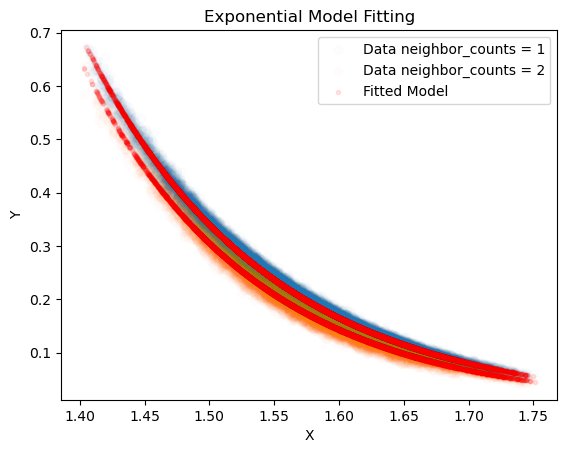

In [75]:
# Generate predictions from the model
with torch.no_grad():  # We don't need gradients for prediction
    predicted = model(X_torch).numpy()

# Plotting the original data
for i in [1, 2]:
    plt.scatter(
        X[:, neighbor_counts == i],
        Y[:, neighbor_counts == i],
        label="Data neighbor_counts = " + str(i),
        alpha=1e-2,
    )

# Plotting the model's predictions
plt.scatter(X, predicted, color="red", label="Fitted Model", marker=".", alpha=0.1)

# Adding labels and title
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Exponential Model Fitting")
plt.legend()

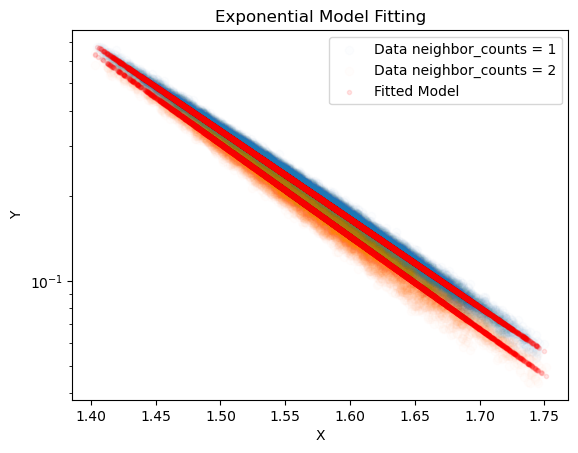

In [76]:
# Generate predictions from the model
with torch.no_grad():  # We don't need gradients for prediction
    predicted = model(X_torch).numpy()

for i in [1, 2]:
    plt.scatter(
        X[:, neighbor_counts == i],
        Y[:, neighbor_counts == i],
        label="Data neighbor_counts = " + str(i),
        alpha=1e-2,
    )

# Plotting the model's predictions
plt.scatter(X, predicted, color="red", label="Fitted Model", marker=".", alpha=0.1)

# Adding labels and title
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Exponential Model Fitting")
plt.legend()
plt.yscale("log")

<>:50: SyntaxWarning: invalid escape sequence '\s'
<>:52: SyntaxWarning: invalid escape sequence '\s'
<>:50: SyntaxWarning: invalid escape sequence '\s'
<>:52: SyntaxWarning: invalid escape sequence '\s'
/var/folders/v_/57lcwyys42x6cnvvnbz7gk4h0000gn/T/ipykernel_2008/1034324577.py:50: SyntaxWarning: invalid escape sequence '\s'
  plt.xlabel("Residuals ($\sigma$)")
/var/folders/v_/57lcwyys42x6cnvvnbz7gk4h0000gn/T/ipykernel_2008/1034324577.py:52: SyntaxWarning: invalid escape sequence '\s'
  plt.title(f"Histogram of Residuals in unit of $\sigma$={sigma}kHz")


Text(0.5, 1.0, 'Histogram of Residuals in unit of $\\sigma$=0.009507072831299666kHz')

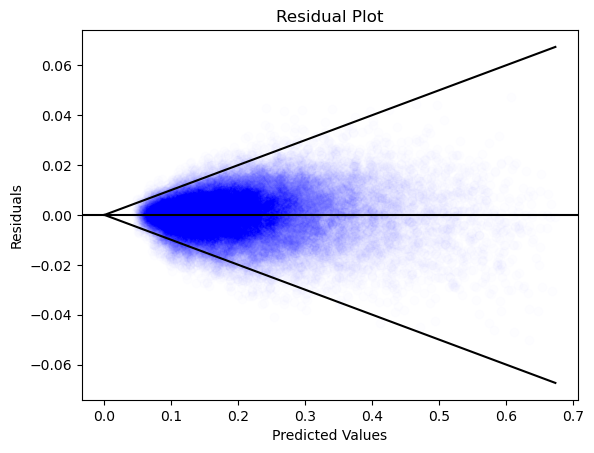

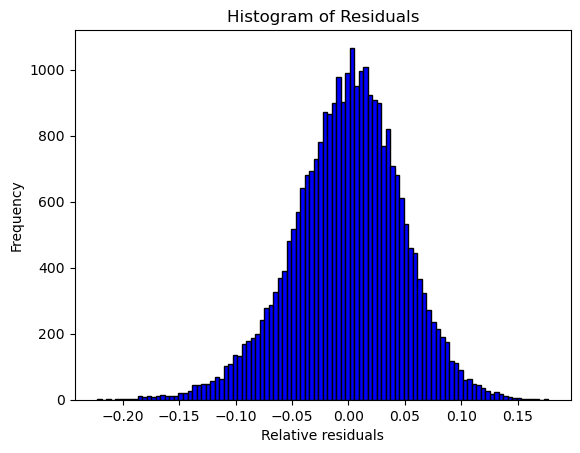

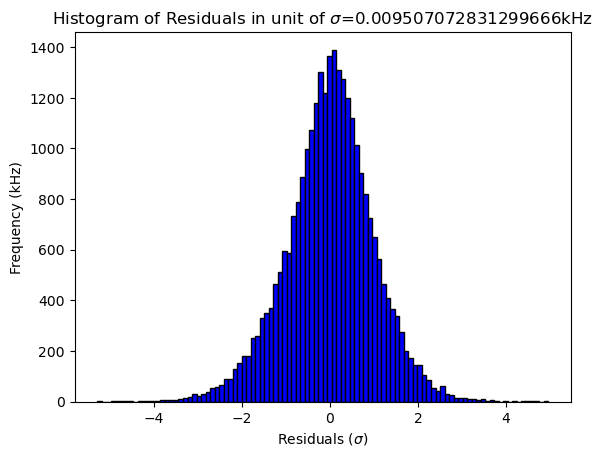

In [77]:
# Function to calculate residuals
def calculate_residuals(model, X, Y):
    model.eval()  # Set the model to evaluation mode
    with torch.no_grad():
        predictions = model(X)
    residuals = Y - predictions
    return predictions, residuals


# Calculate residuals
predictions, residuals = calculate_residuals(model, X_torch, Y_torch)

# Convert to numpy for plotting
predictions_np = predictions.numpy()
residuals_np = residuals.numpy()
sigma = np.std(residuals_np)

# Plotting residuals
plt.figure()
for i in [1, 2]:
    plt.scatter(
        predictions_np[:, neighbor_counts == i],
        residuals_np[:, neighbor_counts == i],
        color="blue",
        alpha=8e-3,
    )
plt.axhline(y=0, color="k", linestyle="-")
x = np.linspace(0, np.max(predictions_np), 100)
plt.plot(x, 0.1 * x, color="k")
plt.plot(x, -0.1 * x, color="k")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")

# Optional: Histogram of Residuals
plt.figure()
plt.hist(
    residuals_np.flatten() / abs(predictions_np.flatten()),
    bins=100,
    color="blue",
    edgecolor="black",
)
plt.xlabel("Relative residuals")
plt.ylabel("Frequency")
plt.title("Histogram of Residuals")

# Optional: Histogram of Residuals ratio to sigma
plt.figure()
plt.hist(residuals_np.flatten() / sigma, bins=100, color="blue", edgecolor="black")
plt.xlabel("Residuals ($\sigma$)")
plt.ylabel("Frequency (kHz)")
plt.title(f"Histogram of Residuals in unit of $\sigma$={sigma}kHz")

Max fitting residual scales ~10% of the data. And R2 means the overall fitting residual is smaller.

## Fit with neighboring atom numbers + CV  (optimal)

In [ ]:
# Custom Model for Exponential Fitting (user-provided)
class ExponentialModel(nn.Module):
    def __init__(self):
        super(ExponentialModel, self).__init__()
        # Initialize parameters a0, a1, b0, b1
        self.a_params = nn.Parameter(
            torch.tensor([-1, -10], dtype=torch.float64)
        )  # For a0, a1
        self.b_params = nn.Parameter(
            torch.tensor([1, 10], dtype=torch.float64)
        )  # For b0, b1

    def forward(self, x_input_dict):
        # x_input_dict is expected to have "rij" and "d" keys
        # Assuming x_input_dict["d"] and x_input_dict["rij"] are per-sample tensors (e.g., shape [N] or [N,1])
        # a_effective = a0*d + a1
        # b_effective = b0*d + b1
        # result = exp(a_effective * rij + b_effective)

        # Ensure operations are element-wise if inputs are 1D tensors per sample
        # If x_input_dict["d"] is shape (N,) or (N,1)
        a_eff = self.a_params[0] * x_input_dict["d"] + self.a_params[1]
        b_eff = self.b_params[0] * x_input_dict["d"] + self.b_params[1]

        return torch.exp(a_eff * x_input_dict["rij"] + b_eff)


# Helper function for the MSE loss criterion used in LBFGS optimization
def mse_criterion_for_lbfgs(outputs, targets):
    mse_loss_fn = nn.MSELoss()  # Averages over all elements
    # targets might be (B, P, 1). torch.var computes variance over all elements.
    var_targets_val = torch.var(targets)
    loss = mse_loss_fn(outputs, targets) / (
        var_targets_val.item() if var_targets_val.item() != 0 else 1.0
    )
    return loss


# Helper function for R2 Score Evaluation
def R2_eval_metric(model: nn.Module, X_data_dict, Y_data_tensor):
    model.eval()
    with torch.no_grad():
        predictions = model(X_data_dict)

    # Flatten to compute metrics over all individual data points (N*P)
    Y_data_flat = Y_data_tensor.reshape(-1)
    predictions_flat = predictions.reshape(-1)

    sst = torch.var(Y_data_flat)
    if sst.item() == 0:
        return -float("inf")

    ssr = torch.mean((Y_data_flat - predictions_flat) ** 2)
    r2 = 1 - (ssr / sst)
    return r2.item()


def train_fold_with_lbfgs_refined(
    model_instance, train_X_dict, train_Y_tensor, l1_lambda, lbfgs_params
):
    model_instance.train()
    optimizer = optim.LBFGS(
        model_instance.parameters(),
        lr=lbfgs_params.get("lr", 0.005),
        max_iter=lbfgs_params.get("max_iter_per_step", 20),
        tolerance_grad=lbfgs_params.get("tol_grad", 1e-7),
        tolerance_change=lbfgs_params.get("tol_change", 1e-9),
        history_size=lbfgs_params.get("history_size", 100),
    )

    def closure():
        optimizer.zero_grad()
        outputs = model_instance(train_X_dict)
        data_loss = mse_criterion_for_lbfgs(outputs, train_Y_tensor)

        l1_penalty_val = 0.0
        if l1_lambda > 0:
            for param in model_instance.parameters():
                l1_penalty_val += torch.abs(param.reshape(-1)).sum()

        total_loss = data_loss + l1_lambda * l1_penalty_val
        total_loss.backward()
        return total_loss

    num_epochs = lbfgs_params.get("epochs", 50)
    tol_loss_change = lbfgs_params.get("tol_loss_change", 1e-9)
    loss_old = torch.inf

    for epoch in range(num_epochs):
        loss_new = optimizer.step(closure)
        if loss_new is None:  # Should not happen
            print("Warning: LBFGS step returned None in fold training.")
            break
        current_loss_val = loss_new.item()
        if abs(loss_old - current_loss_val) < tol_loss_change and epoch > 0:
            break
        loss_old = current_loss_val
    return model_instance


def cross_validate_lbfgs_refined(
    model_class,
    full_X_torch_dict,
    full_Y_torch_tensor,
    l1_lambdas,
    k_folds=5,
    lbfgs_params_cv=None,
    device="cpu",
):
    if lbfgs_params_cv is None:
        lbfgs_params_cv = {
            "lr": 0.005,
            "max_iter_per_step": 20,
            "epochs": 50,
            "tol_grad": 1e-7,
            "tol_change": 1e-9,
            "tol_loss_change": 1e-9,
        }

    # KFold splits along the first dimension of the tensors
    kf = KFold(n_splits=k_folds, shuffle=True, random_state=42)
    # full_Y_torch_tensor has shape (N, P, F_y), indices are for N
    indices = torch.arange(full_Y_torch_tensor.shape[0])

    avg_val_r2_scores_per_lambda = []
    print("Starting Cross-Validation...")

    for l1_lambda in l1_lambdas:
        fold_specific_val_r2_scores = []
        for fold_idx, (train_idx, val_idx) in enumerate(kf.split(indices)):
            # train_idx and val_idx select from the first dimension (N)
            train_X_fold_dict = {
                key: full_X_torch_dict[key][train_idx].to(device)
                for key in full_X_torch_dict
            }
            train_Y_fold_tensor = full_Y_torch_tensor[train_idx].to(device)

            val_X_fold_dict = {
                key: full_X_torch_dict[key][val_idx].to(device)
                for key in full_X_torch_dict
            }
            val_Y_fold_tensor = full_Y_torch_tensor[val_idx].to(device)

            current_model_instance = model_class().to(device)
            if hasattr(current_model_instance, "double"):
                current_model_instance.double()

            train_fold_with_lbfgs_refined(
                model_instance=current_model_instance,
                train_X_dict=train_X_fold_dict,
                train_Y_tensor=train_Y_fold_tensor,
                l1_lambda=l1_lambda,
                lbfgs_params=lbfgs_params_cv,
            )

            val_r2 = R2_eval_metric(
                current_model_instance, val_X_fold_dict, val_Y_fold_tensor
            )
            fold_specific_val_r2_scores.append(val_r2)

        avg_r2_for_this_lambda = (
            np.mean(fold_specific_val_r2_scores)
            if fold_specific_val_r2_scores
            else -float("inf")
        )
        avg_val_r2_scores_per_lambda.append(avg_r2_for_this_lambda)
        print(
            f"  L1 Lambda: {l1_lambda:.3e} -> Avg Validation R2: {avg_r2_for_this_lambda:.4f}"
        )

    if not avg_val_r2_scores_per_lambda:
        print("Warning: No validation scores recorded.")
        return l1_lambdas[0] if l1_lambdas else 0.0, []

    best_lambda_idx = np.argmax(avg_val_r2_scores_per_lambda)
    best_l1_lambda = l1_lambdas[best_lambda_idx]

    print(
        f"\nBest L1 lambda from CV: {best_l1_lambda:.3e} (Avg R2: {avg_val_r2_scores_per_lambda[best_lambda_idx]:.4f})"
    )
    return best_l1_lambda, avg_val_r2_scores_per_lambda


def train_final_model_lbfgs(
    model_class,
    full_X_torch_dict,
    full_Y_torch_tensor,
    best_l1_lambda,
    final_lbfgs_params=None,
    device="cpu",
):
    if final_lbfgs_params is None:
        final_lbfgs_params = {
            "lr": 0.005,
            "max_iter_per_step": 50,
            "epochs": 200,
            "tol_grad": 1e-9,
            "tol_change": 1e-11,
            "tol_loss_change": 1e-11,
        }

    print(f"\nTraining final model with best L1 lambda: {best_l1_lambda:.3e}")
    final_model_instance = model_class().to(device)
    if hasattr(final_model_instance, "double"):
        final_model_instance.double()

    X_data_device_dict = {
        key: full_X_torch_dict[key].to(device) for key in full_X_torch_dict
    }
    Y_data_device_tensor = full_Y_torch_tensor.to(device)

    trained_final_model = train_fold_with_lbfgs_refined(
        model_instance=final_model_instance,
        train_X_dict=X_data_device_dict,
        train_Y_tensor=Y_data_device_tensor,
        l1_lambda=best_l1_lambda,
        lbfgs_params=final_lbfgs_params,
    )

    trained_final_model.eval()
    with torch.no_grad():
        predictions = trained_final_model(X_data_device_dict)
        final_loss_mse_part = mse_criterion_for_lbfgs(predictions, Y_data_device_tensor)

        l1_penalty_val = 0.0
        if best_l1_lambda > 0:
            for param in trained_final_model.parameters():
                l1_penalty_val += torch.abs(param.reshape(-1)).sum()
        total_final_loss = final_loss_mse_part + best_l1_lambda * l1_penalty_val
        final_r2 = R2_eval_metric(
            trained_final_model, X_data_device_dict, Y_data_device_tensor
        )

    print(f"Final model training finished.")
    print(f"  Parameters (a_params): {trained_final_model.a_params.data.cpu().numpy()}")
    print(f"  Parameters (b_params): {trained_final_model.b_params.data.cpu().numpy()}")
    print(f"  Final Model Total Loss (MSE_norm + L1): {total_final_loss.item():.6f}")
    print(f"  Final Model Normalized MSE part: {final_loss_mse_part.item():.6f}")
    print(f"  Final Model R2 on all data: {final_r2:.4f}")
    return trained_final_model

In [269]:
# Data dimensions: (N, P, F)
# N: Number of main samples (e.g., systems, experiments)
# P: Number of pairs (data points) within each main sample
# F: Feature dimension (assumed to be 1 for rij and d in this model's formula)

# Convert data to torch tensors
X_torch = {}
X_torch["rij"] = torch.tensor(X, dtype=torch.float64)
X_torch["d"] = (
    torch.tensor(neighbor_counts, dtype=torch.float64)
    .unsqueeze(0)
    .repeat(X_torch["rij"].shape[0], 1)
)  # Ensure d is broadcastable to match rij shape
Y_torch = torch.tensor(Y, dtype=torch.float64)

num_main_samples = Y_torch.shape[0]  # N: e.g., 50 different experimental setups
num_pairs_per_sample = Y_torch.shape[1]  # P: e.g., 10 (rij,d) pairs within each setup
rij_dim = X_torch["rij"].shape[-1]  # F: Feature dimension for rij
d_dim = X_torch["d"].shape[-1]  # F: Feature dimension for d

device = "cpu"
print(f"Using device: {device}")

# Data does not need to be moved to device here if functions handle it,
# but good practice to do it once if all data fits.
# My functions move data to device per fold/run.

l1_lambdas_to_try = [0.0, 1e-6, 1e-5, 1e-4, 1e-3]
cv_lbfgs_params = {
    "lr": 0.01,
    "max_iter_per_step": 25,
    "epochs": 25,
    "tol_grad": 1e-6,
    "tol_change": 1e-8,
    "tol_loss_change": 1e-8,
}

best_lambda, cv_scores = cross_validate_lbfgs_refined(
    model_class=ExponentialModel,
    full_X_torch_dict=X_torch,
    full_Y_torch_tensor=Y_torch,
    l1_lambdas=l1_lambdas_to_try,
    k_folds=3,  # Use 3-5 folds for CV
    lbfgs_params_cv=cv_lbfgs_params,
    device=device,
)

final_train_lbfgs_params = {
    "lr": 0.01,
    "max_iter_per_step": 40,
    "epochs": 100,
    "tol_grad": 1e-8,
    "tol_change": 1e-10,
    "tol_loss_change": 1e-10,
}

final_trained_model = train_final_model_lbfgs(
    model_class=ExponentialModel,
    full_X_torch_dict=X_torch,
    full_Y_torch_tensor=Y_torch,
    best_l1_lambda=best_lambda,
    final_lbfgs_params=final_train_lbfgs_params,
    device=device,
)

learned_a = final_trained_model.a_params.data.cpu().numpy()
learned_b = final_trained_model.b_params.data.cpu().numpy()
print(f"\nLearned Exponential model equation (approx log(Y)):")
print(
    f"  ({learned_a[0]:.4f} * d + {learned_a[1]:.4f}) * X_rij + ({learned_b[0]:.4f} * d + {learned_b[1]:.4f})"
)

Using device: cpu
Starting Cross-Validation...
  L1 Lambda: 0.000e+00 -> Avg Validation R2: 0.9905
  L1 Lambda: 1.000e-06 -> Avg Validation R2: 0.9905
  L1 Lambda: 1.000e-05 -> Avg Validation R2: 0.9905
  L1 Lambda: 1.000e-04 -> Avg Validation R2: 0.9905
  L1 Lambda: 1.000e-03 -> Avg Validation R2: 0.9432

Best L1 lambda from CV: 1.000e-05 (Avg R2: 0.9905)

Training final model with best L1 lambda: 1.000e-05
Final model training finished.
  Parameters (a_params): [-0.34487818 -6.85145846]
  Parameters (b_params): [0.40888647 9.30687211]
  Final Model Total Loss (MSE_norm + L1): 0.008634
  Final Model Normalized MSE part: 0.008465
  Final Model R2 on all data: 0.9915

Learned Exponential model equation (approx log(Y)):
  (-0.3449 * d + -6.8515) * X_rij + (0.4089 * d + 9.3069)


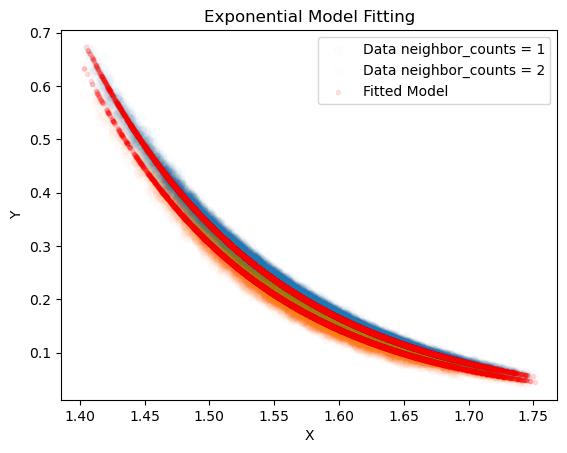

In [270]:
# Generate predictions from the model
with torch.no_grad():  # We don't need gradients for prediction
    predicted = final_trained_model(X_torch).numpy()

# Plotting the original data
for i in [1, 2]:
    plt.scatter(
        X[:, neighbor_counts == i],
        Y[:, neighbor_counts == i],
        label="Data neighbor_counts = " + str(i),
        alpha=1e-2,
    )

# Plotting the model's predictions
plt.scatter(X, predicted, color="red", label="Fitted Model", marker=".", alpha=0.1)

# Adding labels and title
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Exponential Model Fitting")
plt.legend()

<>:50: SyntaxWarning: invalid escape sequence '\s'
<>:52: SyntaxWarning: invalid escape sequence '\s'
<>:50: SyntaxWarning: invalid escape sequence '\s'
<>:52: SyntaxWarning: invalid escape sequence '\s'
/var/folders/v_/57lcwyys42x6cnvvnbz7gk4h0000gn/T/ipykernel_2008/2242393529.py:50: SyntaxWarning: invalid escape sequence '\s'
  plt.xlabel("Residuals ($\sigma$)")
/var/folders/v_/57lcwyys42x6cnvvnbz7gk4h0000gn/T/ipykernel_2008/2242393529.py:52: SyntaxWarning: invalid escape sequence '\s'
  plt.title(f"Histogram of Residuals in unit of $\sigma$={sigma}kHz")


Text(0.5, 1.0, 'Histogram of Residuals in unit of $\\sigma$=0.009507034075577122kHz')

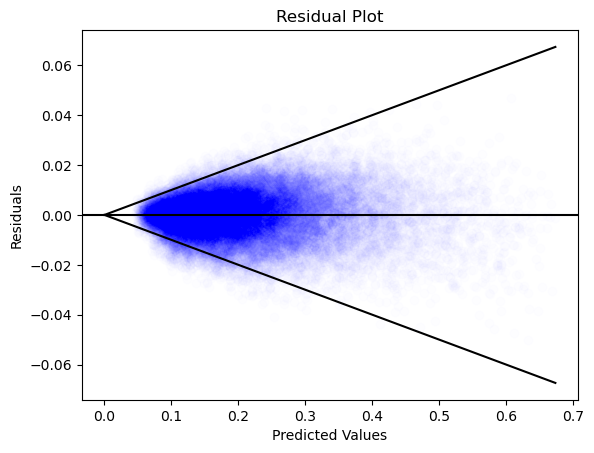

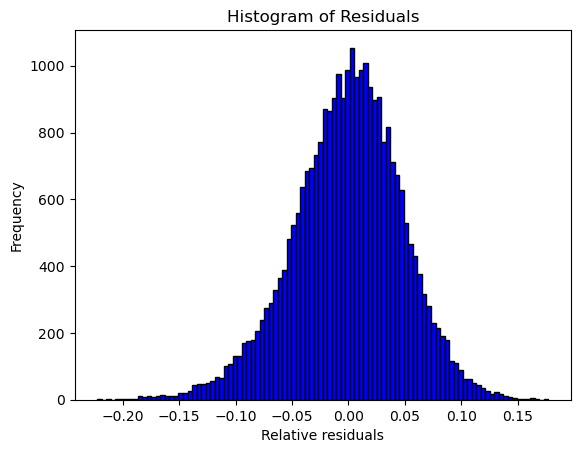

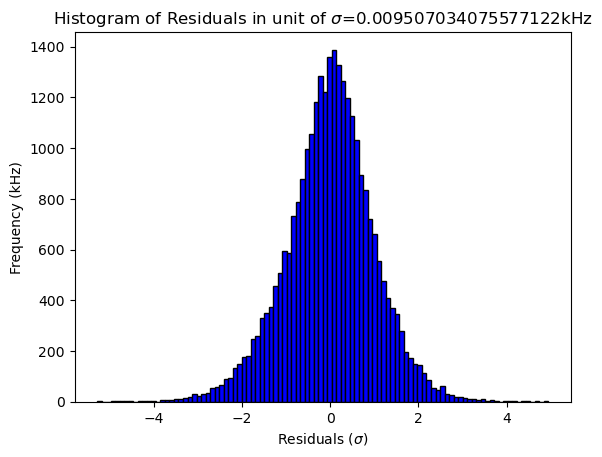

In [271]:
# Function to calculate residuals
def calculate_residuals(model, X, Y):
    model.eval()  # Set the model to evaluation mode
    with torch.no_grad():
        predictions = model(X)
    residuals = Y - predictions
    return predictions, residuals


# Calculate residuals
predictions, residuals = calculate_residuals(final_trained_model, X_torch, Y_torch)

# Convert to numpy for plotting
predictions_np = predictions.numpy()
residuals_np = residuals.numpy()
sigma = np.std(residuals_np)

# Plotting residuals
plt.figure()
for i in [1, 2]:
    plt.scatter(
        predictions_np[:, neighbor_counts == i],
        residuals_np[:, neighbor_counts == i],
        color="blue",
        alpha=8e-3,
    )
plt.axhline(y=0, color="k", linestyle="-")
x = np.linspace(0, np.max(predictions_np), 100)
plt.plot(x, 0.1 * x, color="k")
plt.plot(x, -0.1 * x, color="k")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")

# Optional: Histogram of Residuals
plt.figure()
plt.hist(
    residuals_np.flatten() / abs(predictions_np.flatten()),
    bins=100,
    color="blue",
    edgecolor="black",
)
plt.xlabel("Relative residuals")
plt.ylabel("Frequency")
plt.title("Histogram of Residuals")

# Optional: Histogram of Residuals ratio to sigma
plt.figure()
plt.hist(residuals_np.flatten() / sigma, bins=100, color="blue", edgecolor="black")
plt.xlabel("Residuals ($\sigma$)")
plt.ylabel("Frequency (kHz)")
plt.title(f"Histogram of Residuals in unit of $\sigma$={sigma}kHz")

## Fit w/ neighboring atom numbers + distance + CV

In [244]:
neighbor_rij = []
for i in range(len(other_neighbor)):
    link_neighbor_list = np.array(other_neighbor[i])
    neighbor_rij.append(
        np.sum(
            dat["rij"][mask][:, link_neighbor_list[:, 0], link_neighbor_list[:, 1]],
            axis=-1,
        )
    )
neighbor_rij = np.array(neighbor_rij).T

In [264]:
# Custom Model for Exponential Fitting (user-provided)
class ExponentialModel(nn.Module):
    def __init__(self):
        super(ExponentialModel, self).__init__()
        # Initialize parameters a0, a1, b0, b1
        self.a_params = nn.Parameter(
            torch.tensor([-1, -10], dtype=torch.float64)
        )  # For a0, a1
        self.b_params = nn.Parameter(
            torch.tensor([1, 10], dtype=torch.float64)
        )  # For b0, b1

    def forward(self, x_input_dict):
        # x_input_dict is expected to have "rij" and "d" keys
        # Assuming x_input_dict["d"] and x_input_dict["rij"] are per-sample tensors (e.g., shape [N] or [N,1])
        # a_effective = a0*d + a1
        # b_effective = b0*d + b1
        # result = exp(a_effective * rij + b_effective)

        # Ensure operations are element-wise if inputs are 1D tensors per sample
        # If x_input_dict["d"] is shape (N,P)
        a_eff = self.a_params[0] * x_input_dict["neighbor_rij"] + self.a_params[1]
        b_eff = self.b_params[0] * x_input_dict["neighbor_rij"] + self.b_params[1]

        return torch.exp(a_eff * x_input_dict["rij"] + b_eff)


# Helper function for the MSE loss criterion used in LBFGS optimization
def mse_criterion_for_lbfgs(outputs, targets):
    mse_loss_fn = nn.MSELoss()  # Averages over all elements
    # targets might be (B, P, 1). torch.var computes variance over all elements.
    var_targets_val = torch.var(targets)
    loss = mse_loss_fn(outputs, targets) / (
        var_targets_val.item() if var_targets_val.item() != 0 else 1.0
    )
    return loss


# Helper function for R2 Score Evaluation
def R2_eval_metric(model: nn.Module, X_data_dict, Y_data_tensor):
    model.eval()
    with torch.no_grad():
        predictions = model(X_data_dict)

    # Flatten to compute metrics over all individual data points (N*P)
    Y_data_flat = Y_data_tensor.reshape(-1)
    predictions_flat = predictions.reshape(-1)

    sst = torch.var(Y_data_flat)
    if sst.item() == 0:
        return -float("inf")

    ssr = torch.mean((Y_data_flat - predictions_flat) ** 2)
    r2 = 1 - (ssr / sst)
    return r2.item()


def train_fold_with_lbfgs_refined(
    model_instance, train_X_dict, train_Y_tensor, l1_lambda, lbfgs_params
):
    model_instance.train()
    optimizer = optim.LBFGS(
        model_instance.parameters(),
        lr=lbfgs_params.get("lr", 0.005),
        max_iter=lbfgs_params.get("max_iter_per_step", 20),
        tolerance_grad=lbfgs_params.get("tol_grad", 1e-7),
        tolerance_change=lbfgs_params.get("tol_change", 1e-9),
        history_size=lbfgs_params.get("history_size", 100),
    )

    def closure():
        optimizer.zero_grad()
        outputs = model_instance(train_X_dict)
        data_loss = mse_criterion_for_lbfgs(outputs, train_Y_tensor)

        l1_penalty_val = 0.0
        if l1_lambda > 0:
            for param in model_instance.parameters():
                l1_penalty_val += torch.abs(param.reshape(-1)).sum()

        total_loss = data_loss + l1_lambda * l1_penalty_val
        total_loss.backward()
        return total_loss

    num_epochs = lbfgs_params.get("epochs", 50)
    tol_loss_change = lbfgs_params.get("tol_loss_change", 1e-9)
    loss_old = torch.inf

    for epoch in range(num_epochs):
        loss_new = optimizer.step(closure)
        if loss_new is None:  # Should not happen
            print("Warning: LBFGS step returned None in fold training.")
            break
        current_loss_val = loss_new.item()
        if abs(loss_old - current_loss_val) < tol_loss_change and epoch > 0:
            break
        loss_old = current_loss_val
    return model_instance


def cross_validate_lbfgs_refined(
    model_class,
    full_X_torch_dict,
    full_Y_torch_tensor,
    l1_lambdas,
    k_folds=5,
    lbfgs_params_cv=None,
    device="cpu",
):
    if lbfgs_params_cv is None:
        lbfgs_params_cv = {
            "lr": 0.005,
            "max_iter_per_step": 20,
            "epochs": 50,
            "tol_grad": 1e-7,
            "tol_change": 1e-9,
            "tol_loss_change": 1e-9,
        }

    # KFold splits along the first dimension of the tensors
    kf = KFold(n_splits=k_folds, shuffle=True, random_state=42)
    # full_Y_torch_tensor has shape (N, P, F_y), indices are for N
    indices = torch.arange(full_Y_torch_tensor.shape[0])

    avg_val_r2_scores_per_lambda = []
    print("Starting Cross-Validation...")

    for l1_lambda in l1_lambdas:
        fold_specific_val_r2_scores = []
        for fold_idx, (train_idx, val_idx) in enumerate(kf.split(indices)):
            # train_idx and val_idx select from the first dimension (N)
            train_X_fold_dict = {
                key: full_X_torch_dict[key][train_idx].to(device)
                for key in full_X_torch_dict
            }
            train_Y_fold_tensor = full_Y_torch_tensor[train_idx].to(device)

            val_X_fold_dict = {
                key: full_X_torch_dict[key][val_idx].to(device)
                for key in full_X_torch_dict
            }
            val_Y_fold_tensor = full_Y_torch_tensor[val_idx].to(device)

            current_model_instance = model_class().to(device)
            if hasattr(current_model_instance, "double"):
                current_model_instance.double()

            train_fold_with_lbfgs_refined(
                model_instance=current_model_instance,
                train_X_dict=train_X_fold_dict,
                train_Y_tensor=train_Y_fold_tensor,
                l1_lambda=l1_lambda,
                lbfgs_params=lbfgs_params_cv,
            )

            val_r2 = R2_eval_metric(
                current_model_instance, val_X_fold_dict, val_Y_fold_tensor
            )
            fold_specific_val_r2_scores.append(val_r2)

        avg_r2_for_this_lambda = (
            np.mean(fold_specific_val_r2_scores)
            if fold_specific_val_r2_scores
            else -float("inf")
        )
        avg_val_r2_scores_per_lambda.append(avg_r2_for_this_lambda)
        print(
            f"  L1 Lambda: {l1_lambda:.3e} -> Avg Validation R2: {avg_r2_for_this_lambda:.4f}"
        )

    if not avg_val_r2_scores_per_lambda:
        print("Warning: No validation scores recorded.")
        return l1_lambdas[0] if l1_lambdas else 0.0, []

    best_lambda_idx = np.argmax(avg_val_r2_scores_per_lambda)
    best_l1_lambda = l1_lambdas[best_lambda_idx]

    print(
        f"\nBest L1 lambda from CV: {best_l1_lambda:.3e} (Avg R2: {avg_val_r2_scores_per_lambda[best_lambda_idx]:.4f})"
    )
    return best_l1_lambda, avg_val_r2_scores_per_lambda


def train_final_model_lbfgs(
    model_class,
    full_X_torch_dict,
    full_Y_torch_tensor,
    best_l1_lambda,
    final_lbfgs_params=None,
    device="cpu",
):
    if final_lbfgs_params is None:
        final_lbfgs_params = {
            "lr": 0.005,
            "max_iter_per_step": 50,
            "epochs": 200,
            "tol_grad": 1e-9,
            "tol_change": 1e-11,
            "tol_loss_change": 1e-11,
        }

    print(f"\nTraining final model with best L1 lambda: {best_l1_lambda:.3e}")
    final_model_instance = model_class().to(device)
    if hasattr(final_model_instance, "double"):
        final_model_instance.double()

    X_data_device_dict = {
        key: full_X_torch_dict[key].to(device) for key in full_X_torch_dict
    }
    Y_data_device_tensor = full_Y_torch_tensor.to(device)

    trained_final_model = train_fold_with_lbfgs_refined(
        model_instance=final_model_instance,
        train_X_dict=X_data_device_dict,
        train_Y_tensor=Y_data_device_tensor,
        l1_lambda=best_l1_lambda,
        lbfgs_params=final_lbfgs_params,
    )

    trained_final_model.eval()
    with torch.no_grad():
        predictions = trained_final_model(X_data_device_dict)
        final_loss_mse_part = mse_criterion_for_lbfgs(predictions, Y_data_device_tensor)

        l1_penalty_val = 0.0
        if best_l1_lambda > 0:
            for param in trained_final_model.parameters():
                l1_penalty_val += torch.abs(param.reshape(-1)).sum()
        total_final_loss = final_loss_mse_part + best_l1_lambda * l1_penalty_val
        final_r2 = R2_eval_metric(
            trained_final_model, X_data_device_dict, Y_data_device_tensor
        )

    print(f"Final model training finished.")
    print(f"  Parameters (a_params): {trained_final_model.a_params.data.cpu().numpy()}")
    print(f"  Parameters (b_params): {trained_final_model.b_params.data.cpu().numpy()}")
    print(f"  Final Model Total Loss (MSE_norm + L1): {total_final_loss.item():.6f}")
    print(f"  Final Model Normalized MSE part: {final_loss_mse_part.item():.6f}")
    print(f"  Final Model R2 on all data: {final_r2:.4f}")
    return trained_final_model

In [265]:
# Data dimensions: (N, P, F)
# N: Number of main samples (e.g., systems, experiments)
# P: Number of pairs (data points) within each main sample
# F: Feature dimension (assumed to be 1 for rij and d in this model's formula)

# Convert data to torch tensors
X_torch = {}
X_torch["rij"] = torch.tensor(X, dtype=torch.float64)
X_torch["neighbor_rij"] = torch.tensor(
    neighbor_rij, dtype=torch.float64
)  # Ensure d is broadcastable to match rij shape
Y_torch = torch.tensor(Y, dtype=torch.float64)

num_main_samples = Y_torch.shape[0]  # N: e.g., 50 different experimental setups
num_pairs_per_sample = Y_torch.shape[1]  # P: e.g., 10 (rij,d) pairs within each setup
rij_dim = X_torch["rij"].shape[-1]  # F: Feature dimension for rij
d_dim = X_torch["neighbor_rij"].shape[-1]  # F: Feature dimension for d

device = "cpu"
print(f"Using device: {device}")

# Data does not need to be moved to device here if functions handle it,
# but good practice to do it once if all data fits.
# My functions move data to device per fold/run.

l1_lambdas_to_try = [0.0, 1e-6, 1e-5, 1e-4, 1e-3]
cv_lbfgs_params = {
    "lr": 0.005,
    "max_iter_per_step": 25,
    "epochs": 25,
    "tol_grad": 1e-6,
    "tol_change": 1e-8,
    "tol_loss_change": 1e-8,
}

best_lambda, cv_scores = cross_validate_lbfgs_refined(
    model_class=ExponentialModel,
    full_X_torch_dict=X_torch,
    full_Y_torch_tensor=Y_torch,
    l1_lambdas=l1_lambdas_to_try,
    k_folds=3,  # Use 3-5 folds for CV
    lbfgs_params_cv=cv_lbfgs_params,
    device=device,
)

final_train_lbfgs_params = {
    "lr": 0.01,
    "max_iter_per_step": 40,
    "epochs": 100,
    "tol_grad": 1e-8,
    "tol_change": 1e-10,
    "tol_loss_change": 1e-10,
}

final_trained_model = train_final_model_lbfgs(
    model_class=ExponentialModel,
    full_X_torch_dict=X_torch,
    full_Y_torch_tensor=Y_torch,
    best_l1_lambda=best_lambda,
    final_lbfgs_params=final_train_lbfgs_params,
    device=device,
)

learned_a = final_trained_model.a_params.data.cpu().numpy()
learned_b = final_trained_model.b_params.data.cpu().numpy()
print(f"\nLearned Exponential model equation (approx log(Y)):")
print(
    f"  ({learned_a[0]:.4f} * d + {learned_a[1]:.4f}) * X_rij + ({learned_b[0]:.4f} * d + {learned_b[1]:.4f})"
)

Using device: cpu
Starting Cross-Validation...
  L1 Lambda: 0.000e+00 -> Avg Validation R2: 0.8938
  L1 Lambda: 1.000e-06 -> Avg Validation R2: 0.8938
  L1 Lambda: 1.000e-05 -> Avg Validation R2: 0.8938
  L1 Lambda: 1.000e-04 -> Avg Validation R2: 0.8933
  L1 Lambda: 1.000e-03 -> Avg Validation R2: 0.8925

Best L1 lambda from CV: 0.000e+00 (Avg R2: 0.8938)

Training final model with best L1 lambda: 0.000e+00
Final model training finished.
  Parameters (a_params): [-0.20385901 -6.90430718]
  Parameters (b_params): [0.24190251 9.37783055]
  Final Model Total Loss (MSE_norm + L1): 0.010195
  Final Model Normalized MSE part: 0.010195
  Final Model R2 on all data: 0.9898

Learned Exponential model equation (approx log(Y)):
  (-0.2039 * d + -6.9043) * X_rij + (0.2419 * d + 9.3778)


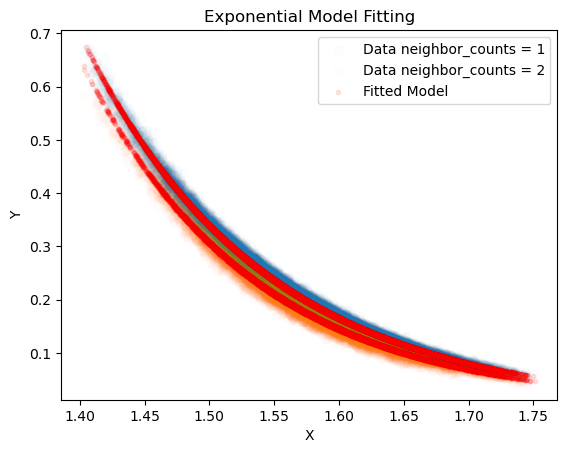

In [266]:
# Generate predictions from the model
with torch.no_grad():  # We don't need gradients for prediction
    predicted = final_trained_model(X_torch).numpy()

# Plotting the original data
for i in [1, 2]:
    plt.scatter(
        X[:, neighbor_counts == i],
        Y[:, neighbor_counts == i],
        label="Data neighbor_counts = " + str(i),
        alpha=1e-2,
    )

# Plotting the model's predictions
plt.scatter(X, predicted, color="red", label="Fitted Model", marker=".", alpha=0.1)

# Adding labels and title
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Exponential Model Fitting")
plt.legend()

<>:50: SyntaxWarning: invalid escape sequence '\s'
<>:52: SyntaxWarning: invalid escape sequence '\s'
<>:50: SyntaxWarning: invalid escape sequence '\s'
<>:52: SyntaxWarning: invalid escape sequence '\s'
/var/folders/v_/57lcwyys42x6cnvvnbz7gk4h0000gn/T/ipykernel_2008/2242393529.py:50: SyntaxWarning: invalid escape sequence '\s'
  plt.xlabel("Residuals ($\sigma$)")
/var/folders/v_/57lcwyys42x6cnvvnbz7gk4h0000gn/T/ipykernel_2008/2242393529.py:52: SyntaxWarning: invalid escape sequence '\s'
  plt.title(f"Histogram of Residuals in unit of $\sigma$={sigma}kHz")


Text(0.5, 1.0, 'Histogram of Residuals in unit of $\\sigma$=0.010433217342659786kHz')

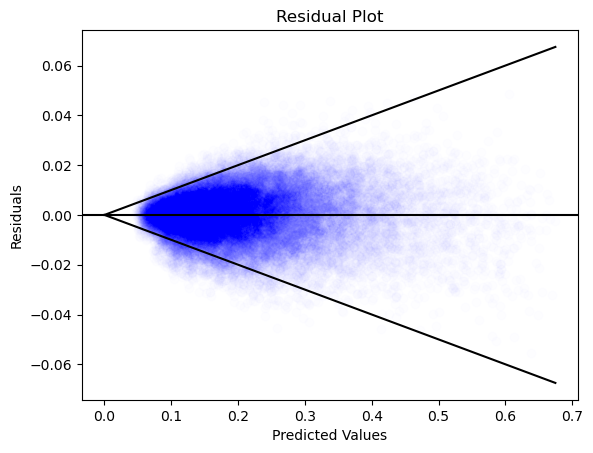

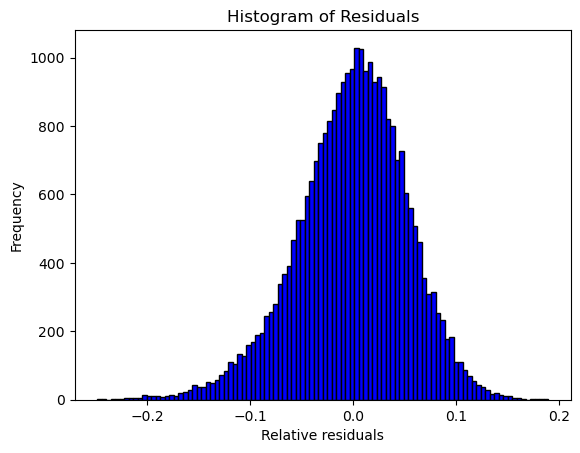

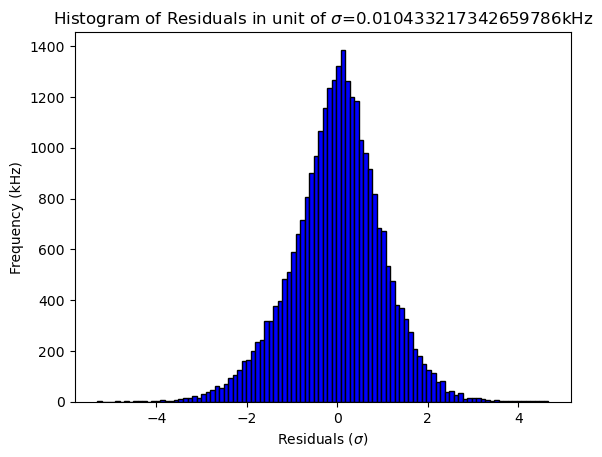

In [267]:
# Function to calculate residuals
def calculate_residuals(model, X, Y):
    model.eval()  # Set the model to evaluation mode
    with torch.no_grad():
        predictions = model(X)
    residuals = Y - predictions
    return predictions, residuals


# Calculate residuals
predictions, residuals = calculate_residuals(final_trained_model, X_torch, Y_torch)

# Convert to numpy for plotting
predictions_np = predictions.numpy()
residuals_np = residuals.numpy()
sigma = np.std(residuals_np)

# Plotting residuals
plt.figure()
for i in [1, 2]:
    plt.scatter(
        predictions_np[:, neighbor_counts == i],
        residuals_np[:, neighbor_counts == i],
        color="blue",
        alpha=8e-3,
    )
plt.axhline(y=0, color="k", linestyle="-")
x = np.linspace(0, np.max(predictions_np), 100)
plt.plot(x, 0.1 * x, color="k")
plt.plot(x, -0.1 * x, color="k")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")

# Optional: Histogram of Residuals
plt.figure()
plt.hist(
    residuals_np.flatten() / abs(predictions_np.flatten()),
    bins=100,
    color="blue",
    edgecolor="black",
)
plt.xlabel("Relative residuals")
plt.ylabel("Frequency")
plt.title("Histogram of Residuals")

# Optional: Histogram of Residuals ratio to sigma
plt.figure()
plt.hist(residuals_np.flatten() / sigma, bins=100, color="blue", edgecolor="black")
plt.xlabel("Residuals ($\sigma$)")
plt.ylabel("Frequency (kHz)")
plt.title(f"Histogram of Residuals in unit of $\sigma$={sigma}kHz")

## Regression network + CV

CV not working as optimal parameter is large.

In [ ]:
class TunnelingNet(nn.Module):
    # For numerical stability (e.g., in division for projection)
    epsilon = 1e-9
    device = "mps" if torch.backends.mps.is_available() else "cpu"
    dtype = torch.float32

    def __init__(self, num_max_edges: int = 4):
        super().__init__()
        self.num_max_edges = num_max_edges

        # Define learnable weights and bias
        self.w0_delta_r_norm = nn.Parameter(
            -7.6811 * torch.ones(1)
        )  # w_0 for ||Delta r||
        self.w_projections = nn.Parameter(
            0.1 * torch.ones(num_max_edges)
        )  # w_1, ..., w_4 for D1, ..., D4
        self.wv_logV = nn.Parameter(torch.ones(1))  # w_v for |logV_i + logV_j|
        self.bias = nn.Parameter(10 * torch.ones(1))  # b

    def calculate_grid_edge_vectors(self, R_global: torch.Tensor) -> torch.Tensor:
        """
        Calculates edge vectors (to 4 cardinal neighbors)
        for each node in a grid, given their coordinates.

        Edge vectors are defined as R_neighbor - R_node.
        The 4 edge slots are ordered: 0: Up, 1: Down, 2: Left, 3: Right.

        Args:
            R_global (torch.Tensor): Node coordinates of shape (B, Lx, Ly, 2),
                                    where B is batch size, Lx/Ly are grid dimensions.

        Returns:
            tuple[torch.Tensor, torch.Tensor]:
                - D_global (torch.Tensor): Edge vectors, shape (B, Lx, Ly, 4, 2).
                                        Invalid edge vectors will be [0,0].
        """
        B, Lx, Ly, _ = R_global.shape

        # Initialize output tensors
        # D_global stores the actual (dx, dy) vectors
        D_global = torch.zeros(
            B, Lx, Ly, self.num_max_edges, 2, device=self.device, dtype=self.dtype
        )

        # --- Calculate edge vectors and masks for each direction ---

        # Slot 0: Up neighbor (R_node_at(u-1,v) - R_node_at(u,v))
        # Valid for nodes in rows u = 1 to Lx-1 (i.e., current node index u > 0)
        if Lx > 1:
            # Nodes that have an "up" neighbor are R_global[:, 1:Lx, :, :]
            # Their "up" neighbors are R_global[:, 0:Lx-1, :, :]
            D_global[:, 1:Lx, :, 0, :] = (
                R_global[:, 0 : Lx - 1, :, :] - R_global[:, 1:Lx, :, :]
            )

        # Slot 1: Down neighbor (R_node_at(u+1,v) - R_node_at(u,v))
        # Valid for nodes in rows u = 0 to Lx-2 (i.e., current node index u < Lx-1)
        if Lx > 1:
            # Nodes that have a "down" neighbor are R_global[:, 0:Lx-1, :, :]
            # Their "down" neighbors are R_global[:, 1:Lx, :, :]
            D_global[:, 0 : Lx - 1, :, 1, :] = (
                R_global[:, 1:Lx, :, :] - R_global[:, 0 : Lx - 1, :, :]
            )

        # Slot 2: Left neighbor (R_node_at(u,v-1) - R_node_at(u,v))
        # Valid for nodes in columns v = 1 to Ly-1 (i.e., current node index v > 0)
        if Ly > 1:
            # Nodes that have a "left" neighbor are R_global[:, :, 1:Ly, :]
            # Their "left" neighbors are R_global[:, :, 0:Ly-1, :]
            D_global[:, :, 1:Ly, 2, :] = (
                R_global[:, :, 0 : Ly - 1, :] - R_global[:, :, 1:Ly, :]
            )

        # Slot 3: Right neighbor (R_node_at(u,v+1) - R_node_at(u,v))
        # Valid for nodes in columns v = 0 to Ly-2 (i.e., current node index v < Ly-1)
        if Ly > 1:
            # Nodes that have a "right" neighbor are R_global[:, :, 0:Ly-1, :]
            # Their "right" neighbors are R_global[:, :, 1:Ly, :]
            D_global[:, :, 0 : Ly - 1, 3, :] = (
                R_global[:, :, 1:Ly, :] - R_global[:, :, 0 : Ly - 1, :]
            )

        return D_global

    def forward(self, x_dict: dict) -> torch.Tensor:
        """
        Computes S_ij for specified pairs (i,j) across a batch based on the revised logic.

        Args:
            x_dict (dict): A dictionary containing input tensors:
                'R_global': Coordinates (batch, Lx, Ly, 2).
                'logV_global': LogV values (batch, Lx, Ly).
                'idx_i_batch': Source site indices (batch, num_pairs, 2) -> (ui,vi).
                'idx_j_batch': Target site indices (batch, num_pairs, 2) -> (uj,vj).

        Returns:
            torch.Tensor: Computed S_ij values (batch, num_pairs).
        """
        R_global = x_dict["R_global"]
        D_global = self.calculate_grid_edge_vectors(R_global)
        logV_global = x_dict["logV_global"]
        idx_i_batch = x_dict["idx_i_batch"]
        idx_j_batch = x_dict["idx_j_batch"]

        batch_size, num_pairs, _ = idx_i_batch.shape

        # --- Helper for gathering: (B,1) for broadcasting with (B,P) pair indices ---
        batch_indices_bp = torch.arange(batch_size, device=self.device).unsqueeze(1)

        # --- 1. Gather data for source sites i ---
        ui_i = idx_i_batch[..., 0]  # (B, P)
        vi_i = idx_i_batch[..., 1]  # (B, P)

        r_i_pairs = R_global[batch_indices_bp, ui_i, vi_i, :]  # (B, P, 2)
        d_i_vectors = D_global[
            batch_indices_bp, ui_i, vi_i, :, :
        ]  # (B, P, num_max_edges, 2)
        logV_i_pairs = logV_global[batch_indices_bp, ui_i, vi_i]  # (B, P)

        # --- 2. Gather data for target sites j ---
        ui_j = idx_j_batch[..., 0]  # (B, P)
        vi_j = idx_j_batch[..., 1]  # (B, P)

        r_j_pairs = R_global[batch_indices_bp, ui_j, vi_j, :]  # (B, P, 2)
        d_j_vectors = D_global[
            batch_indices_bp, ui_j, vi_j, :, :
        ]  # (B, P, num_max_edges, 2)
        logV_j_pairs = logV_global[batch_indices_bp, ui_j, vi_j]  # (B, P)

        # --- 3. Compute differences (Step 2 from description) ---
        # Delta r = r_j - r_i
        delta_r_vector = r_j_pairs - r_i_pairs  # (B, P, 2)
        # Delta d_k = d_ik - d_jk, vanishing if not valid
        delta_d_vectors = d_i_vectors - d_j_vectors  # (B, P, num_max_edges, 2)

        # --- 4. Compute norm of Delta r and projections (Step 3 from description) ---
        # Norm of Delta r: ||Delta r||
        norm_delta_r = torch.norm(delta_r_vector, p=2, dim=-1)  # (B, P)

        # Unit vector u_delta_r. Add epsilon to norm_delta_r for stability if norm_delta_r is 0.
        # Denominator shape: (B,P,1) for broadcasting
        u_delta_r = delta_r_vector / (
            norm_delta_r.unsqueeze(-1) + self.epsilon
        )  # (B, P, 2)

        # Projections Dk = (delta_d_vectors_k) . u_delta_r
        # u_delta_r.unsqueeze(2) gives (B, P, 1, 2) to broadcast with delta_d_vectors (B,P,N_edges,2)
        # Result of sum over last dim (dot product) is (B, P, num_max_edges)
        projections_Dk = torch.sum(
            delta_d_vectors * u_delta_r.unsqueeze(2), dim=-1
        )  # (B, P, num_max_edges)

        # --- 5. Weighted sum (Step 4 from description) ---
        # Term 0: w_0 * ||Delta r||
        term0_val = self.w0_delta_r_norm * norm_delta_r  # (B, P)

        # Term for projections: sum(w_k * D_k) for k=1 to num_max_edges
        # self.w_projections is (num_max_edges,). Reshape for broadcasting: (1, 1, num_max_edges)
        # projections_Dk is (B,P,num_max_edges)
        term_projections_sum = torch.sum(
            self.w_projections.view(1, 1, self.num_max_edges) * projections_Dk, dim=2
        )  # (B, P)

        # Term for logV: w_v * |logV_i + logV_j|
        logV_sum_abs = torch.abs(logV_i_pairs + logV_j_pairs)  # (B, P)
        term_logV_val = self.wv_logV * logV_sum_abs  # (B, P)

        # Total sum S_ij
        S_ij_pairs = (
            term0_val + term_projections_sum + term_logV_val + self.bias
        )  # (B, P)

        # --- 6. Return S_ij (as per loss function: MSE(S_ij, log(t_ij_true))) ---
        return S_ij_pairs

In [ ]:
class DictDataset(Dataset):
    def __init__(self, X: dict, Y: dict):
        """
        X, Y: dicts mapping feature names → tensors of shape (N, …)
        Assumes all tensors in X (and in Y) share the same first dimension N.
        """
        self.X = X
        self.Y = Y

        # sanity check: all tensors in X have same length
        lengths = {t.shape[0] for t in X.values()}
        if len(lengths) != 1:
            raise ValueError(f"Inconsistent X lengths: {lengths}")
        lengths = {t.shape[0] for t in Y.values()}
        if len(lengths) != 1:
            raise ValueError(f"Inconsistent Y lengths: {lengths}")
        if list(X.values())[0].shape[0] != list(Y.values())[0].shape[0]:
            raise ValueError("X and Y must have same number of samples")

        self.N = list(X.values())[0].shape[0]

    def __len__(self):
        return self.N

    def __getitem__(self, idx):
        # grab the idx-th slice from each tensor
        x_item = {k: v[idx] for k, v in self.X.items()}
        y_item = {k: v[idx] for k, v in self.Y.items()}
        return x_item, y_item


def R2(pred, Y):
    sst = torch.std(Y) ** 2
    ssr = torch.mean((Y - pred) ** 2)
    r2 = 1 - ssr / sst
    return r2.item()


def train_epoch(model, optimizer, data_loader, l1_lambda, device, floor=1e-9):
    model.train()
    total_loss = 0.0
    # lossfunc = nn.MSELoss(reduction="sum")
    lossfunc = R2
    for x_batch, y_batch in data_loader:
        x = {k: v.to(device) for k, v in x_batch.items()}
        y = next(iter(y_batch.values())).to(device)

        optimizer.zero_grad()
        pred = model(x)
        # MSE on log-space
        base_loss = lossfunc(
            pred, torch.log(y + floor)
        )  # Avoid log(0) issues :contentReference[oaicite:1]{index=1}
        # L1 penalty on all parameters
        l1_penalty = sum(p.abs().sum() for p in model.parameters())
        loss = (
            base_loss + l1_lambda * l1_penalty
        )  # L1 regularization :contentReference[oaicite:2]{index=2}
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * y.size(0)
    return total_loss / len(data_loader.dataset)


def cross_validate(
    model,
    optimizer,
    dataset,
    l1_lambdas,
    k_folds=5,
    epochs=10,
    batch_size=32,
    device="cpu",
):
    kf = KFold(
        n_splits=k_folds, shuffle=True, random_state=42
    )  # K-Fold split :contentReference[oaicite:3]{index=3}
    val_scores = []

    for l1_lambda in l1_lambdas:
        print(f"Training with L1 lambda: {l1_lambda}")
        fold_losses = []
        for train_idx, val_idx in kf.split(dataset):
            train_subset = torch.utils.data.Subset(dataset, train_idx)
            val_subset = torch.utils.data.Subset(dataset, val_idx)
            train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True)
            val_loader = DataLoader(val_subset, batch_size=batch_size)

            # train for a few epochs
            for epoch in range(epochs):
                train_epoch(model, optimizer, train_loader, l1_lambda, device)

            # evaluate on validation fold
            model.eval()
            with torch.no_grad():
                # lossfunc = nn.MSELoss(reduction="sum")
                lossfunc = R2
                val_loss = 0.0
                for x, y in val_loader:
                    x, y = {k: v.to(device) for k, v in x.items()}, next(
                        iter(y.values())
                    ).to(device)
                    pred = model(x)
                    val_loss += lossfunc(pred, torch.log(y)).item()
                fold_losses.append(val_loss / len(val_subset))
            print(f"Training fold {len(fold_losses) + 1} loss: {fold_losses[-1]:.4f}")
        val_scores.append(np.mean(fold_losses))
        print(f"Validation loss for lambda {l1_lambda}: {val_scores[-1]:.4f}")
    # pick lambda with lowest validation loss
    best_idx = int(np.argmin(val_scores))
    return l1_lambdas[best_idx], val_scores

In [216]:
# Instantiate model, loss, optimizer
nodes, links, node_idx_pair = sqr_lattice(np.array([L, L]))
i_idx, j_idx = links[:, 0], links[:, 1]

dtype = torch.float32
Y_torch = {"t_ij": torch.tensor(dat["t_ij"][mask][:, i_idx, j_idx], dtype=dtype)}

# Convert to 2D indices for i_idx, j_idx
i_idx = np.array(np.unravel_index(i_idx, (L, L))).T
j_idx = np.array(np.unravel_index(j_idx, (L, L))).T
device = "mps" if torch.backends.mps.is_available() else "cpu"
model = TunnelingNet().to(device)
criterion = (
    nn.MSELoss()
)  # MSE on (prediction, log_y) :contentReference[oaicite:11]{index=11}
optimizer = optim.Adam(
    model.parameters(), lr=1e-3
)  # Adam optimizer :contentReference[oaicite:12]{index=12}

# Convert data to torch tensors
X_torch = {}
X_torch["R_global"] = torch.tensor(dat["trap_centers"][mask], dtype=dtype).reshape(
    -1, L, L, 2
)
X_torch["logV_global"] = torch.log(
    torch.tensor(dat["V_offset"][mask], dtype=dtype).reshape(-1, L, L)
)
batch_size = X_torch["R_global"].shape[0]
X_torch["idx_i_batch"] = (
    torch.tensor(i_idx, dtype=torch.long).unsqueeze(0).expand(batch_size, -1, -1)
)
X_torch["idx_j_batch"] = (
    torch.tensor(j_idx, dtype=torch.long).unsqueeze(0).expand(batch_size, -1, -1)
)

max_iter = 1_000
epoches = 100
n_fold = 5
seed = 42
batch_size = 32
# suppose X = {'r': torch.randn(100, L, 2), 'V': torch.rand(100, L)}
#         Y = {'y': torch.rand(100, P)}
dataset = DictDataset(X_torch, Y_torch)
lambdas = np.logspace(-4, -1, 4)
best_lambda, scores = cross_validate(
    model,
    optimizer,
    dataset,
    lambdas,
    k_folds=n_fold,
    epochs=10,
    batch_size=batch_size,
    device=device,
)
print("Best L1 λ:", best_lambda)

Training with L1 lambda: 0.0001
Training fold 2 loss: 12282.4454
Training fold 3 loss: 11164.1641
Training fold 4 loss: 10133.9231
Training fold 5 loss: 9161.5623
Training fold 6 loss: 8270.8501
Validation loss for lambda 0.0001: 10202.5890
Training with L1 lambda: 0.001
Training fold 2 loss: 7447.0046
Training fold 3 loss: 6677.3497
Training fold 4 loss: 5973.0278
Training fold 5 loss: 5314.7567
Training fold 6 loss: 4717.9002
Validation loss for lambda 0.001: 6026.0078
Training with L1 lambda: 0.01
Training fold 2 loss: 4173.1366
Training fold 3 loss: 3672.0131
Training fold 4 loss: 3222.1112
Training fold 5 loss: 2811.7175
Training fold 6 loss: 2448.3744
Validation loss for lambda 0.01: 3265.4706
Training with L1 lambda: 0.1
Training fold 2 loss: 2127.6352
Training fold 3 loss: 1843.2324
Training fold 4 loss: 1597.3219
Training fold 5 loss: 1383.0946
Training fold 6 loss: 1200.8803
Validation loss for lambda 0.1: 1630.4329
Best L1 λ: 0.1


In [238]:
# Retrain on full data with best λ
full_loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
for epoch in range(epoches):
    loss = train_epoch(model, optimizer, full_loader, 0, device)
    print(f"Epoch {epoch+1}: Loss = {loss:.4f}")

Epoch 1: Loss = 0.9883
Epoch 2: Loss = 0.9883
Epoch 3: Loss = 0.9883
Epoch 4: Loss = 0.9883
Epoch 5: Loss = 0.9883
Epoch 6: Loss = 0.9883
Epoch 7: Loss = 0.9883
Epoch 8: Loss = 0.9883
Epoch 9: Loss = 0.9883
Epoch 10: Loss = 0.9883
Epoch 11: Loss = 0.9883
Epoch 12: Loss = 0.9883
Epoch 13: Loss = 0.9883
Epoch 14: Loss = 0.9883
Epoch 15: Loss = 0.9883
Epoch 16: Loss = 0.9883
Epoch 17: Loss = 0.9883
Epoch 18: Loss = 0.9883
Epoch 19: Loss = 0.9883
Epoch 20: Loss = 0.9883
Epoch 21: Loss = 0.9883
Epoch 22: Loss = 0.9883
Epoch 23: Loss = 0.9883
Epoch 24: Loss = 0.9883
Epoch 25: Loss = 0.9883
Epoch 26: Loss = 0.9883
Epoch 27: Loss = 0.9883
Epoch 28: Loss = 0.9883
Epoch 29: Loss = 0.9883
Epoch 30: Loss = 0.9883
Epoch 31: Loss = 0.9883
Epoch 32: Loss = 0.9883
Epoch 33: Loss = 0.9883
Epoch 34: Loss = 0.9883
Epoch 35: Loss = 0.9883
Epoch 36: Loss = 0.9883
Epoch 37: Loss = 0.9883
Epoch 38: Loss = 0.9883
Epoch 39: Loss = 0.9883
Epoch 40: Loss = 0.9883
Epoch 41: Loss = 0.9883
Epoch 42: Loss = 0.9883
E

In [239]:
# Print model parameters
for name, param in model.named_parameters():
    print(f"{name}: {param.data}")

w0_delta_r_norm: tensor([-7.7127], device='mps:0')
w_projections: tensor([0.0657, 0.0675, 0.0922, 0.0931], device='mps:0')
wv_logV: tensor([0.0185], device='mps:0')
bias: tensor([10.3958], device='mps:0')


<>:60: SyntaxWarning: invalid escape sequence '\s'
<>:62: SyntaxWarning: invalid escape sequence '\s'
<>:60: SyntaxWarning: invalid escape sequence '\s'
<>:62: SyntaxWarning: invalid escape sequence '\s'
/var/folders/v_/57lcwyys42x6cnvvnbz7gk4h0000gn/T/ipykernel_31552/3630475066.py:60: SyntaxWarning: invalid escape sequence '\s'
  plt.xlabel("Residuals ($\sigma$)")
/var/folders/v_/57lcwyys42x6cnvvnbz7gk4h0000gn/T/ipykernel_31552/3630475066.py:62: SyntaxWarning: invalid escape sequence '\s'
  plt.title(f"Histogram of Residuals in unit of $\sigma$={sigma}kHz")


Text(0.5, 1.0, 'Histogram of Residuals in unit of $\\sigma$=0.010238890536129475kHz')

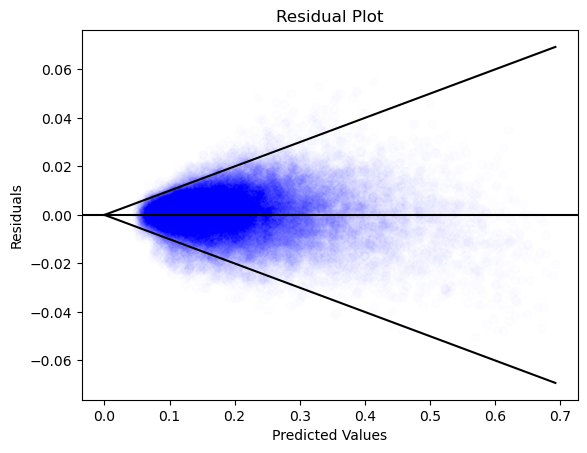

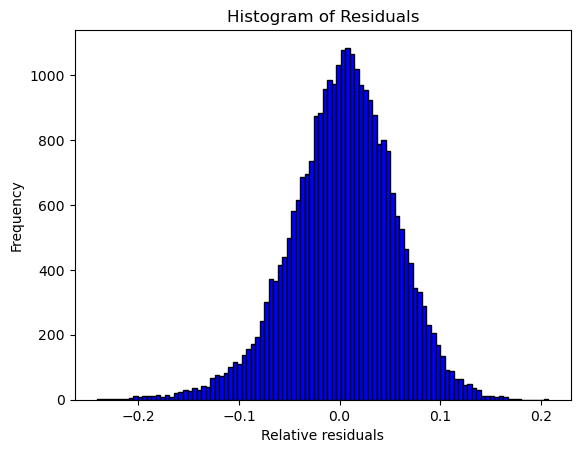

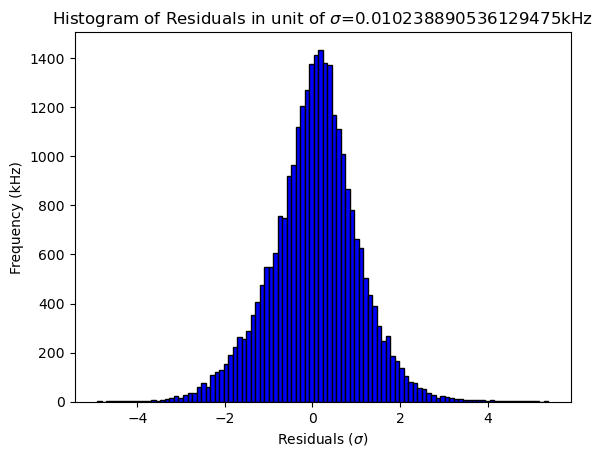

In [240]:
# Generate predictions from the model
with torch.no_grad():  # We don't need gradients for prediction
    X, Y = {k: v.to(device) for k, v in X_torch.items()}, next(
        iter(Y_torch.values())
    ).to(device)
    predicted = model(X).cpu().numpy()


# Function to calculate residuals
def calculate_residuals(model, X, Y):
    model.eval()  # Set the model to evaluation mode
    with torch.no_grad():
        X, Y = {k: v.to(device) for k, v in X_torch.items()}, next(
            iter(Y_torch.values())
        ).to(device)
        predictions = torch.exp(model(X))
    residuals = Y - predictions
    return predictions, residuals


# Calculate residuals
predictions, residuals = calculate_residuals(model, X_torch, Y_torch)

# Convert to numpy for plotting
predictions_np = predictions.cpu().numpy()
residuals_np = residuals.cpu().numpy()
sigma = np.std(residuals_np)

# Plotting residuals
plt.figure()
plt.scatter(
    predictions_np,
    residuals_np,
    color="blue",
    alpha=8e-3,
)
plt.axhline(y=0, color="k", linestyle="-")
x = np.linspace(0, np.max(predictions_np), 100)
plt.plot(x, 0.1 * x, color="k")
plt.plot(x, -0.1 * x, color="k")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")

# Optional: Histogram of Residuals
plt.figure()
plt.hist(
    residuals_np.flatten() / abs(predictions_np.flatten()),
    bins=100,
    color="blue",
    edgecolor="black",
)
plt.xlabel("Relative residuals")
plt.ylabel("Frequency")
plt.title("Histogram of Residuals")

# Optional: Histogram of Residuals ratio to sigma
plt.figure()
plt.hist(residuals_np.flatten() / sigma, bins=100, color="blue", edgecolor="black")
plt.xlabel("Residuals ($\sigma$)")
plt.ylabel("Frequency (kHz)")
plt.title(f"Histogram of Residuals in unit of $\sigma$={sigma}kHz")

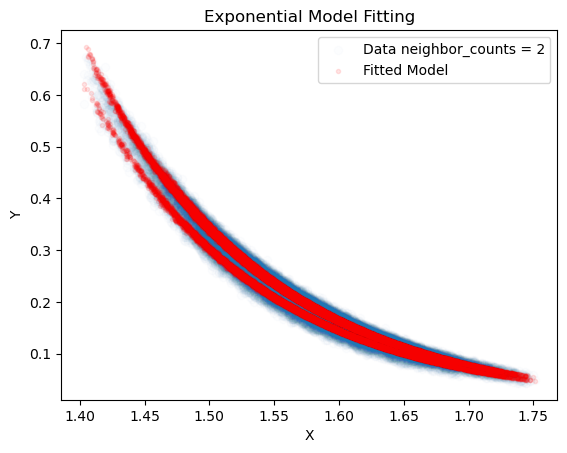

In [241]:
X = nnr[mask]
Y = nnt[mask]

# Plotting the original data
plt.scatter(X, Y, label="Data neighbor_counts = " + str(i), alpha=1e-2)

# Plotting the model's predictions
plt.scatter(X, predictions_np, color="red", label="Fitted Model", marker=".", alpha=0.1)

# Adding labels and title
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Exponential Model Fitting")
plt.legend()

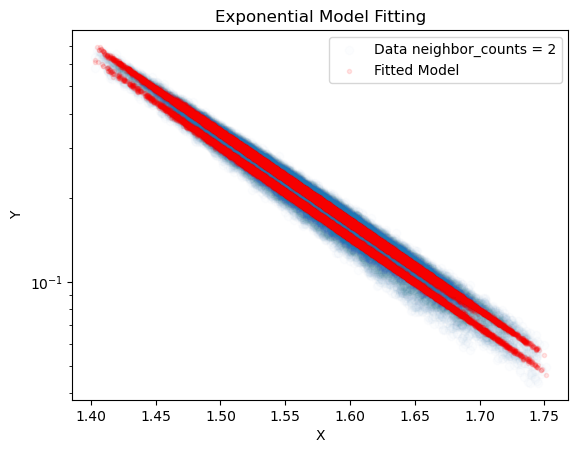

In [242]:
X = nnr[mask]
Y = nnt[mask]

# Plotting the original data
plt.scatter(X, Y, label="Data neighbor_counts = " + str(i), alpha=1e-2)

# Plotting the model's predictions
plt.scatter(X, predictions_np, color="red", label="Fitted Model", marker=".", alpha=0.1)

# Adding labels and title
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Exponential Model Fitting")
plt.yscale("log")
plt.legend()

Not as effective as the previous model.

More param + less accuracy.

## Regression network 2

Network on the exp slope.

In [57]:
class TunnelingNet(nn.Module):
    # For numerical stability (e.g., in division for projection)
    epsilon = 1e-9
    device = "mps" if torch.backends.mps.is_available() else "cpu"
    dtype = torch.float32

    def __init__(self, num_max_edges: int = 4):
        super().__init__()
        self.num_max_edges = num_max_edges

        # Define learnable weights and bias
        self.w0_delta_r_norm = nn.Parameter(
            -7.6811 * torch.ones(1)
        )  # w_0 for ||Delta r||
        self.w_projections = nn.Parameter(
            torch.ones(num_max_edges)
        )  # w_1, ..., w_4 for D1, ..., D4
        self.wv_logV = nn.Parameter(torch.ones(1))  # w_v for |logV_i + logV_j|
        self.bias = nn.Parameter(10 * torch.ones(1))  # b

    def calculate_grid_edge_vectors(self, R_global: torch.Tensor) -> torch.Tensor:
        """
        Calculates edge vectors (to 4 cardinal neighbors)
        for each node in a grid, given their coordinates.

        Edge vectors are defined as R_neighbor - R_node.
        The 4 edge slots are ordered: 0: Up, 1: Down, 2: Left, 3: Right.

        Args:
            R_global (torch.Tensor): Node coordinates of shape (B, Lx, Ly, 2),
                                    where B is batch size, Lx/Ly are grid dimensions.

        Returns:
            tuple[torch.Tensor, torch.Tensor]:
                - D_global (torch.Tensor): Edge vectors, shape (B, Lx, Ly, 4, 2).
                                        Invalid edge vectors will be [0,0].
        """
        B, Lx, Ly, _ = R_global.shape

        # Initialize output tensors
        # D_global stores the actual (dx, dy) vectors
        D_global = torch.zeros(
            B, Lx, Ly, self.num_max_edges, 2, device=self.device, dtype=self.dtype
        )

        # --- Calculate edge vectors and masks for each direction ---

        # Slot 0: Up neighbor (R_node_at(u-1,v) - R_node_at(u,v))
        # Valid for nodes in rows u = 1 to Lx-1 (i.e., current node index u > 0)
        if Lx > 1:
            # Nodes that have an "up" neighbor are R_global[:, 1:Lx, :, :]
            # Their "up" neighbors are R_global[:, 0:Lx-1, :, :]
            D_global[:, 1:Lx, :, 0, :] = (
                R_global[:, 0 : Lx - 1, :, :] - R_global[:, 1:Lx, :, :]
            )

        # Slot 1: Down neighbor (R_node_at(u+1,v) - R_node_at(u,v))
        # Valid for nodes in rows u = 0 to Lx-2 (i.e., current node index u < Lx-1)
        if Lx > 1:
            # Nodes that have a "down" neighbor are R_global[:, 0:Lx-1, :, :]
            # Their "down" neighbors are R_global[:, 1:Lx, :, :]
            D_global[:, 0 : Lx - 1, :, 1, :] = (
                R_global[:, 1:Lx, :, :] - R_global[:, 0 : Lx - 1, :, :]
            )

        # Slot 2: Left neighbor (R_node_at(u,v-1) - R_node_at(u,v))
        # Valid for nodes in columns v = 1 to Ly-1 (i.e., current node index v > 0)
        if Ly > 1:
            # Nodes that have a "left" neighbor are R_global[:, :, 1:Ly, :]
            # Their "left" neighbors are R_global[:, :, 0:Ly-1, :]
            D_global[:, :, 1:Ly, 2, :] = (
                R_global[:, :, 0 : Ly - 1, :] - R_global[:, :, 1:Ly, :]
            )

        # Slot 3: Right neighbor (R_node_at(u,v+1) - R_node_at(u,v))
        # Valid for nodes in columns v = 0 to Ly-2 (i.e., current node index v < Ly-1)
        if Ly > 1:
            # Nodes that have a "right" neighbor are R_global[:, :, 0:Ly-1, :]
            # Their "right" neighbors are R_global[:, :, 1:Ly, :]
            D_global[:, :, 0 : Ly - 1, 3, :] = (
                R_global[:, :, 1:Ly, :] - R_global[:, :, 0 : Ly - 1, :]
            )

        return D_global

    def forward(self, x_dict: dict) -> torch.Tensor:
        """
        Computes S_ij for specified pairs (i,j) across a batch based on the revised logic.

        Args:
            x_dict (dict): A dictionary containing input tensors:
                'R_global': Coordinates (batch, Lx, Ly, 2).
                'logV_global': LogV values (batch, Lx, Ly).
                'idx_i_batch': Source site indices (batch, num_pairs, 2) -> (ui,vi).
                'idx_j_batch': Target site indices (batch, num_pairs, 2) -> (uj,vj).

        Returns:
            torch.Tensor: Computed S_ij values (batch, num_pairs).
        """
        R_global = x_dict["R_global"]
        D_global = self.calculate_grid_edge_vectors(R_global)
        logV_global = x_dict["logV_global"]
        idx_i_batch = x_dict["idx_i_batch"]
        idx_j_batch = x_dict["idx_j_batch"]

        batch_size, num_pairs, _ = idx_i_batch.shape

        # --- Helper for gathering: (B,1) for broadcasting with (B,P) pair indices ---
        batch_indices_bp = torch.arange(batch_size, device=self.device).unsqueeze(1)

        # --- 1. Gather data for source sites i ---
        ui_i = idx_i_batch[..., 0]  # (B, P)
        vi_i = idx_i_batch[..., 1]  # (B, P)

        r_i_pairs = R_global[batch_indices_bp, ui_i, vi_i, :]  # (B, P, 2)
        d_i_vectors = D_global[
            batch_indices_bp, ui_i, vi_i, :, :
        ]  # (B, P, num_max_edges, 2)
        logV_i_pairs = logV_global[batch_indices_bp, ui_i, vi_i]  # (B, P)

        # --- 2. Gather data for target sites j ---
        ui_j = idx_j_batch[..., 0]  # (B, P)
        vi_j = idx_j_batch[..., 1]  # (B, P)

        r_j_pairs = R_global[batch_indices_bp, ui_j, vi_j, :]  # (B, P, 2)
        d_j_vectors = D_global[
            batch_indices_bp, ui_j, vi_j, :, :
        ]  # (B, P, num_max_edges, 2)
        logV_j_pairs = logV_global[batch_indices_bp, ui_j, vi_j]  # (B, P)

        # --- 3. Compute differences (Step 2 from description) ---
        # Delta r = r_j - r_i
        delta_r_vector = r_j_pairs - r_i_pairs  # (B, P, 2)
        # Delta d_k = d_ik - d_jk, vanishing if not valid
        delta_d_vectors = d_i_vectors - d_j_vectors  # (B, P, num_max_edges, 2)

        # --- 4. Compute norm of Delta r and projections (Step 3 from description) ---
        # Norm of Delta r: ||Delta r||
        norm_delta_r = torch.norm(delta_r_vector, p=2, dim=-1)  # (B, P)

        # Unit vector u_delta_r. Add epsilon to norm_delta_r for stability if norm_delta_r is 0.
        # Denominator shape: (B,P,1) for broadcasting
        u_delta_r = delta_r_vector / (
            norm_delta_r.unsqueeze(-1) + self.epsilon
        )  # (B, P, 2)

        # Projections Dk = (delta_d_vectors_k) . u_delta_r
        # u_delta_r.unsqueeze(2) gives (B, P, 1, 2) to broadcast with delta_d_vectors (B,P,N_edges,2)
        # Result of sum over last dim (dot product) is (B, P, num_max_edges)
        projections_Dk = torch.sum(
            delta_d_vectors * u_delta_r.unsqueeze(2), dim=-1
        )  # (B, P, num_max_edges)

        # --- 5. Weighted sum (Step 4 from description) ---
        # Term for projections: sum(w_k * D_k) for k=1 to num_max_edges
        # self.w_projections is (num_max_edges,). Reshape for broadcasting: (1, 1, num_max_edges)
        # projections_Dk is (B,P,num_max_edges)
        term_projections_sum = torch.sum(
            self.w_projections.view(1, 1, self.num_max_edges) * projections_Dk, dim=2
        )  # (B, P)

        # Term: w_0 * ||Delta r||
        term0_val = (
            term_projections_sum + self.w0_delta_r_norm
        ) * norm_delta_r  # (B, P)

        # Term for logV: w_v * |logV_i + logV_j|
        logV_sum_abs = torch.abs(logV_i_pairs + logV_j_pairs)  # (B, P)

        # Total sum S_ij
        S_ij_pairs = term0_val + self.wv_logV * logV_sum_abs + self.bias  # (B, P)

        # --- 6. Return S_ij (as per loss function: MSE(S_ij, log(t_ij_true))) ---
        return S_ij_pairs

In [58]:
class DictDataset(Dataset):
    def __init__(self, X: dict, Y: dict):
        """
        X, Y: dicts mapping feature names → tensors of shape (N, …)
        Assumes all tensors in X (and in Y) share the same first dimension N.
        """
        self.X = X
        self.Y = Y

        # sanity check: all tensors in X have same length
        lengths = {t.shape[0] for t in X.values()}
        if len(lengths) != 1:
            raise ValueError(f"Inconsistent X lengths: {lengths}")
        lengths = {t.shape[0] for t in Y.values()}
        if len(lengths) != 1:
            raise ValueError(f"Inconsistent Y lengths: {lengths}")
        if list(X.values())[0].shape[0] != list(Y.values())[0].shape[0]:
            raise ValueError("X and Y must have same number of samples")

        self.N = list(X.values())[0].shape[0]

    def __len__(self):
        return self.N

    def __getitem__(self, idx):
        # grab the idx-th slice from each tensor
        x_item = {k: v[idx] for k, v in self.X.items()}
        y_item = {k: v[idx] for k, v in self.Y.items()}
        return x_item, y_item


def R2(pred, Y):
    sst = torch.std(Y) ** 2
    ssr = torch.mean((Y - pred) ** 2)
    r2 = 1 - ssr / sst
    return r2.item()


def train_epoch(model, optimizer, data_loader, l1_lambda, device, floor=1e-9):
    model.train()
    total_loss = 0.0
    # lossfunc = nn.MSELoss(reduction="sum")
    lossfunc = R2
    for x_batch, y_batch in data_loader:
        x = {k: v.to(device) for k, v in x_batch.items()}
        y = next(iter(y_batch.values())).to(device)

        optimizer.zero_grad()
        pred = model(x)
        # MSE on log-space
        base_loss = lossfunc(
            pred, torch.log(y + floor)
        )  # Avoid log(0) issues :contentReference[oaicite:1]{index=1}
        # L1 penalty on all parameters
        l1_penalty = sum(p.abs().sum() for p in model.parameters())
        loss = (
            base_loss + l1_lambda * l1_penalty
        )  # L1 regularization :contentReference[oaicite:2]{index=2}
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * y.size(0)
    return total_loss / len(data_loader.dataset)


def cross_validate(
    model,
    optimizer,
    dataset,
    l1_lambdas,
    k_folds=5,
    epochs=10,
    batch_size=32,
    device="cpu",
):
    kf = KFold(
        n_splits=k_folds, shuffle=True, random_state=42
    )  # K-Fold split :contentReference[oaicite:3]{index=3}
    val_scores = []

    for l1_lambda in l1_lambdas:
        print(f"Training with L1 lambda: {l1_lambda}")
        fold_losses = []
        for train_idx, val_idx in kf.split(dataset):
            train_subset = torch.utils.data.Subset(dataset, train_idx)
            val_subset = torch.utils.data.Subset(dataset, val_idx)
            train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True)
            val_loader = DataLoader(val_subset, batch_size=batch_size)

            # train for a few epochs
            for epoch in range(epochs):
                train_epoch(model, optimizer, train_loader, l1_lambda, device)

            # evaluate on validation fold
            model.eval()
            with torch.no_grad():
                # lossfunc = nn.MSELoss(reduction="sum")
                lossfunc = R2
                val_loss = 0.0
                for x, y in val_loader:
                    x, y = {k: v.to(device) for k, v in x.items()}, next(
                        iter(y.values())
                    ).to(device)
                    pred = model(x)
                    val_loss += lossfunc(pred, torch.log(y)).item()
                fold_losses.append(val_loss / len(val_subset))
            print(f"Training fold {len(fold_losses) + 1} loss: {fold_losses[-1]:.4f}")
        val_scores.append(np.mean(fold_losses))
        print(f"Validation loss for lambda {l1_lambda}: {val_scores[-1]:.4f}")
    # pick lambda with lowest validation loss
    best_idx = int(np.argmin(val_scores))
    return l1_lambdas[best_idx], val_scores

In [59]:
# Instantiate model, loss, optimizer
nodes, links, node_idx_pair = sqr_lattice(np.array([L, L]))
i_idx, j_idx = links[:, 0], links[:, 1]

dtype = torch.float32
Y_torch = {"t_ij": torch.tensor(dat["t_ij"][mask][:, i_idx, j_idx], dtype=dtype)}

# Convert to 2D indices for i_idx, j_idx
i_idx = np.array(np.unravel_index(i_idx, (L, L))).T
j_idx = np.array(np.unravel_index(j_idx, (L, L))).T
device = "mps" if torch.backends.mps.is_available() else "cpu"
model = TunnelingNet().to(device)
criterion = (
    nn.MSELoss()
)  # MSE on (prediction, log_y) :contentReference[oaicite:11]{index=11}
optimizer = optim.Adam(
    model.parameters(), lr=1e-3
)  # Adam optimizer :contentReference[oaicite:12]{index=12}

# Convert data to torch tensors
X_torch = {}
X_torch["R_global"] = torch.tensor(dat["trap_centers"][mask], dtype=dtype).reshape(
    -1, L, L, 2
)
X_torch["logV_global"] = torch.log(
    torch.tensor(dat["V_offset"][mask], dtype=dtype).reshape(-1, L, L)
)
batch_size = X_torch["R_global"].shape[0]
X_torch["idx_i_batch"] = (
    torch.tensor(i_idx, dtype=torch.long).unsqueeze(0).expand(batch_size, -1, -1)
)
X_torch["idx_j_batch"] = (
    torch.tensor(j_idx, dtype=torch.long).unsqueeze(0).expand(batch_size, -1, -1)
)

max_iter = 1_000
epoches = 50
n_fold = 5
seed = 42
batch_size = 32
# suppose X = {'r': torch.randn(100, L, 2), 'V': torch.rand(100, L)}
#         Y = {'y': torch.rand(100, P)}
dataset = DictDataset(X_torch, Y_torch)
lambdas = np.logspace(-4, -1, 4)

In [60]:
# Retrain on full data with best λ
full_loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
for epoch in range(epoches):
    loss = train_epoch(model, optimizer, full_loader, 0, device)
    print(f"Epoch {epoch+1}: Loss = {loss:.4f}")

# Print model parameters
for name, param in model.named_parameters():
    print(f"{name}: {param.data}")

Epoch 1: Loss = -11.7445
Epoch 2: Loss = -11.7479
Epoch 3: Loss = -11.7525
Epoch 4: Loss = -11.7390
Epoch 5: Loss = -11.7402
Epoch 6: Loss = -11.7416
Epoch 7: Loss = -11.7513
Epoch 8: Loss = -11.7459
Epoch 9: Loss = -11.7577
Epoch 10: Loss = -11.7375
Epoch 11: Loss = -11.7553
Epoch 12: Loss = -11.7720
Epoch 13: Loss = -11.7576
Epoch 14: Loss = -11.7538
Epoch 15: Loss = -11.7620
Epoch 16: Loss = -11.7447
Epoch 17: Loss = -11.7493
Epoch 18: Loss = -11.7448
Epoch 19: Loss = -11.7496
Epoch 20: Loss = -11.7546
Epoch 21: Loss = -11.7442
Epoch 22: Loss = -11.7616
Epoch 23: Loss = -11.7570
Epoch 24: Loss = -11.7529
Epoch 25: Loss = -11.7530
Epoch 26: Loss = -11.7480
Epoch 27: Loss = -11.7497
Epoch 28: Loss = -11.7607
Epoch 29: Loss = -11.7479
Epoch 30: Loss = -11.7589
Epoch 31: Loss = -11.7560
Epoch 32: Loss = -11.7432
Epoch 33: Loss = -11.7375
Epoch 34: Loss = -11.7444
Epoch 35: Loss = -11.7586
Epoch 36: Loss = -11.7413
Epoch 37: Loss = -11.7481
Epoch 38: Loss = -11.7452
Epoch 39: Loss = -11.

<>:60: SyntaxWarning: invalid escape sequence '\s'
<>:62: SyntaxWarning: invalid escape sequence '\s'
<>:60: SyntaxWarning: invalid escape sequence '\s'
<>:62: SyntaxWarning: invalid escape sequence '\s'
/var/folders/v_/57lcwyys42x6cnvvnbz7gk4h0000gn/T/ipykernel_2008/3630475066.py:60: SyntaxWarning: invalid escape sequence '\s'
  plt.xlabel("Residuals ($\sigma$)")
/var/folders/v_/57lcwyys42x6cnvvnbz7gk4h0000gn/T/ipykernel_2008/3630475066.py:62: SyntaxWarning: invalid escape sequence '\s'
  plt.title(f"Histogram of Residuals in unit of $\sigma$={sigma}kHz")


Text(0.5, 1.0, 'Histogram of Residuals in unit of $\\sigma$=0.035431910306215286kHz')

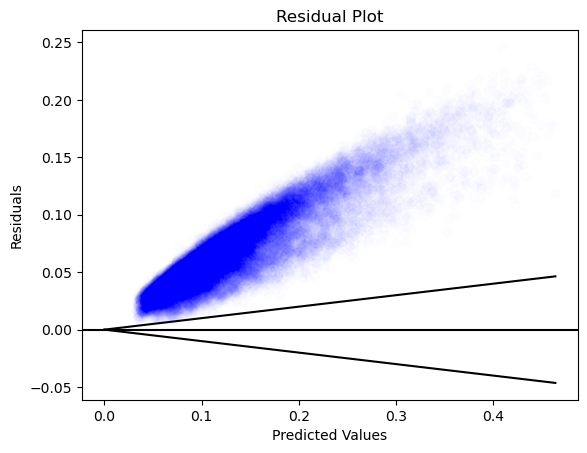

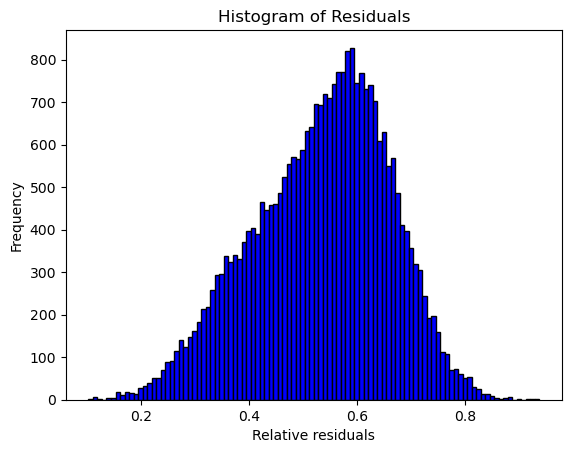

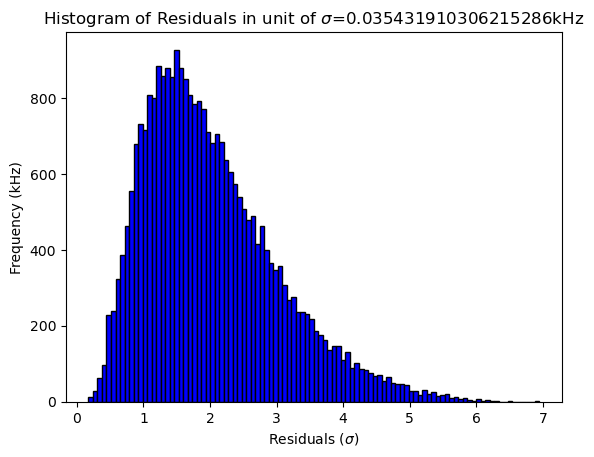

In [54]:
# Generate predictions from the model
with torch.no_grad():  # We don't need gradients for prediction
    X, Y = {k: v.to(device) for k, v in X_torch.items()}, next(
        iter(Y_torch.values())
    ).to(device)
    predicted = model(X).cpu().numpy()


# Function to calculate residuals
def calculate_residuals(model, X, Y):
    model.eval()  # Set the model to evaluation mode
    with torch.no_grad():
        X, Y = {k: v.to(device) for k, v in X_torch.items()}, next(
            iter(Y_torch.values())
        ).to(device)
        predictions = torch.exp(model(X))
    residuals = Y - predictions
    return predictions, residuals


# Calculate residuals
predictions, residuals = calculate_residuals(model, X_torch, Y_torch)

# Convert to numpy for plotting
predictions_np = predictions.cpu().numpy()
residuals_np = residuals.cpu().numpy()
sigma = np.std(residuals_np)

# Plotting residuals
plt.figure()
plt.scatter(
    predictions_np,
    residuals_np,
    color="blue",
    alpha=8e-3,
)
plt.axhline(y=0, color="k", linestyle="-")
x = np.linspace(0, np.max(predictions_np), 100)
plt.plot(x, 0.1 * x, color="k")
plt.plot(x, -0.1 * x, color="k")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")

# Optional: Histogram of Residuals
plt.figure()
plt.hist(
    residuals_np.flatten() / abs(predictions_np.flatten()),
    bins=100,
    color="blue",
    edgecolor="black",
)
plt.xlabel("Relative residuals")
plt.ylabel("Frequency")
plt.title("Histogram of Residuals")

# Optional: Histogram of Residuals ratio to sigma
plt.figure()
plt.hist(residuals_np.flatten() / sigma, bins=100, color="blue", edgecolor="black")
plt.xlabel("Residuals ($\sigma$)")
plt.ylabel("Frequency (kHz)")
plt.title(f"Histogram of Residuals in unit of $\sigma$={sigma}kHz")

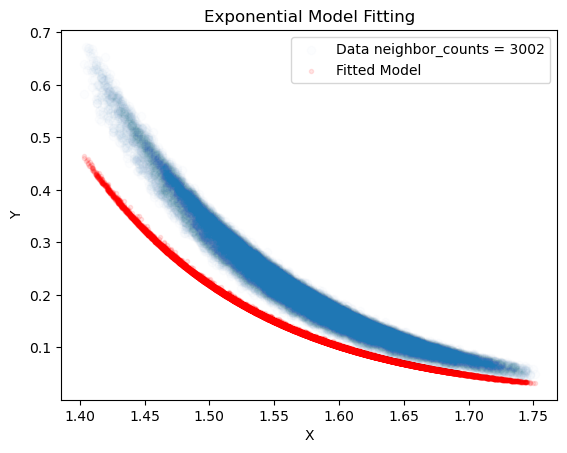

In [55]:
X = nnr[mask]
Y = nnt[mask]

# Plotting the original data
plt.scatter(X, Y, label="Data neighbor_counts = " + str(i), alpha=1e-2)

# Plotting the model's predictions
plt.scatter(X, predictions_np, color="red", label="Fitted Model", marker=".", alpha=0.1)

# Adding labels and title
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Exponential Model Fitting")
plt.legend()